# 01 — Exploratory Data Analysis

Project: Home Credit Default Risk / Credit Risk Scoring Service

Цель ноутбука:

- понять структуру исходных данных;
- проверить распределение таргета;
- найти пропуски;
- изучить числовые и категориальные признаки;
- посмотреть признаки, связанные с дефолтом;
- подготовить идеи для feature engineering.

In [48]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

In [3]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(PROJECT_ROOT)
print(RAW_DATA_DIR)

/Users/artem/PycharmProjects/credit-risk-scoring-service
/Users/artem/PycharmProjects/credit-risk-scoring-service/data/raw


In [5]:
application_train = pd.read_csv(RAW_DATA_DIR / "application_train.csv")
application_test = pd.read_csv(RAW_DATA_DIR / "application_test.csv")

In [6]:
application_train.shape, application_test.shape

((307511, 122), (48744, 121))

In [7]:
application_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [8]:
application_train.columns.tolist()

['SK_ID_CURR',
 'TARGET',
 'NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'REGION_POPULATION_RELATIVE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'OWN_CAR_AGE',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'OCCUPATION_TYPE',
 'CNT_FAM_MEMBERS',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY',
 'WEEKDAY_APPR_PROCESS_START',
 'HOUR_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'ORGANIZATION_TYPE',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'APARTMENTS_AVG',
 'BASEMENTAREA_AVG',
 'YEARS_BEGINEXPLUATATION_A

In [9]:
application_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 286.2 MB


## 2. Target distribution

Проверим распределение целевой переменной `TARGET`.

В датасете Home Credit:

- `TARGET = 0` — клиент вернул кредит без серьёзных проблем;
- `TARGET = 1` — у клиента были проблемы с выплатой кредита.

In [10]:
target_counts = application_train["TARGET"].value_counts()
target_share = application_train["TARGET"].value_counts(normalize=True)

target_distribution = pd.DataFrame(
    {
        "count": target_counts,
        "share": target_share,
    }
)

target_distribution

,count,share
TARGET,,
0,282686,0.919271
1,24825,0.080729


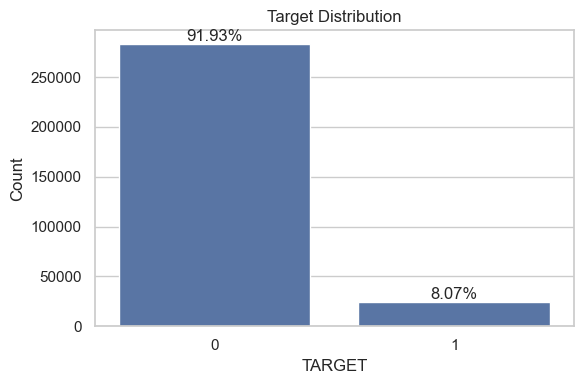

In [12]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(data=application_train, x="TARGET")

plt.title("Target Distribution")
plt.xlabel("TARGET")
plt.ylabel("Count")

for p in ax.patches:
    count = int(p.get_height())
    share = count / len(application_train)

    ax.annotate(
        f"{share:.2%}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

### Target distribution conclusions

Целевая переменная сильно несбалансирована:

- класс `0` занимает примерно 92%;
- класс `1` занимает примерно 8%.

Это значит, что в задаче кредитного скоринга нельзя полагаться только на accuracy.

Для оценки моделей лучше использовать:

- ROC-AUC;
- PR-AUC;
- precision;
- recall;
- F1-score;
- KS statistic;
- default rate by score bands.

## 3. Data types and missing values

Теперь посмотрим:

- какие типы данных есть в `application_train`;
- сколько числовых и категориальных признаков;
- в каких колонках больше всего пропусков.

Это важно, потому что дальше для разных типов признаков будут разные способы обработки.

In [13]:
application_train.dtypes.value_counts()

float64    65
int64      41
str        16
Name: count, dtype: int64

In [14]:
numeric_features = application_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = application_train.select_dtypes(include=["object", "string"]).columns.tolist()

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

Numeric features: 106
Categorical features: 16


In [15]:
categorical_features

['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'ORGANIZATION_TYPE',
 'FONDKAPREMONT_MODE',
 'HOUSETYPE_MODE',
 'WALLSMATERIAL_MODE',
 'EMERGENCYSTATE_MODE']

In [16]:
# посмотрим на пропуски категориальных признаков
categorical_summary = pd.DataFrame(
    {
        "n_unique": application_train[categorical_features].nunique(),
        "missing_count": application_train[categorical_features].isna().sum(),
        "missing_rate": application_train[categorical_features].isna().mean(),
    }
).sort_values("missing_rate", ascending=False)

categorical_summary

,n_unique,missing_count,missing_rate
FONDKAPREMONT_MODE,4,210295,0.683862
WALLSMATERIAL_MODE,7,156341,0.508408
HOUSETYPE_MODE,3,154297,0.501761
EMERGENCYSTATE_MODE,2,145755,0.473983
OCCUPATION_TYPE,18,96391,0.313455
NAME_TYPE_SUITE,7,1292,0.004201
NAME_CONTRACT_TYPE,2,0,0.000000
CODE_GENDER,3,0,0.000000
FLAG_OWN_CAR,2,0,0.000000
FLAG_OWN_REALTY,2,0,0.000000


### Categorical features observations

В `application_train` найдено 16 категориальных признаков.

Наибольшая доля пропусков наблюдается у признаков, связанных с характеристиками жилья:

- `FONDKAPREMONT_MODE`;
- `WALLSMATERIAL_MODE`;
- `HOUSETYPE_MODE`;
- `EMERGENCYSTATE_MODE`.

Также заметная доля пропусков есть у признака `OCCUPATION_TYPE`.

На этапе feature engineering такие пропуски не стоит автоматически удалять. Возможные варианты обработки:

- заполнить значением `Unknown`;
- создать отдельный missing-indicator;
- оставить пропуски для моделей, которые умеют с ними работать;
- обработать как отдельную категорию при WOE-биннинге.

## 4. Missing values

Посмотрим долю пропусков по всем признакам.

Пропуски важны, потому что:

- они могут означать отсутствие информации о клиенте;
- в кредитном скоринге сам факт отсутствия информации может быть связан с риском;
- разные модели по-разному работают с пропусками.

In [17]:
missing_values = (
    application_train
    .isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_rate")
    .reset_index()
    .rename(columns={"index": "feature"})
)

missing_values["missing_count"] = (
    application_train[missing_values["feature"]]
    .isna()
    .sum()
    .values
)

missing_values.head(30)

,feature,missing_rate,missing_count
0,COMMONAREA_MEDI,0.698723,214865
1,COMMONAREA_AVG,0.698723,214865
2,COMMONAREA_MODE,0.698723,214865
3,NONLIVINGAPARTMENTS_MODE,0.694330,213514
4,NONLIVINGAPARTMENTS_AVG,0.694330,213514
5,NONLIVINGAPARTMENTS_MEDI,0.694330,213514
6,FONDKAPREMONT_MODE,0.683862,210295
7,LIVINGAPARTMENTS_MODE,0.683550,210199
8,LIVINGAPARTMENTS_AVG,0.683550,210199
9,LIVINGAPARTMENTS_MEDI,0.683550,210199


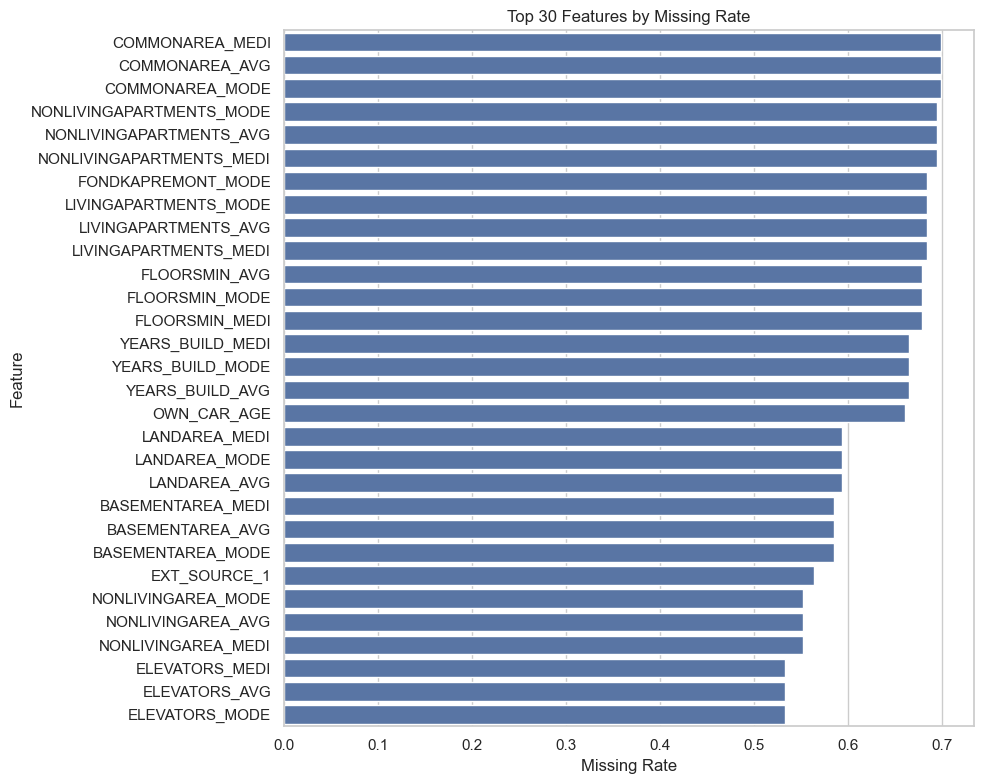

In [18]:
plt.figure(figsize=(10, 8))

top_missing = missing_values.head(30)

sns.barplot(
    data=top_missing,
    x="missing_rate",
    y="feature",
)

plt.title("Top 30 Features by Missing Rate")
plt.xlabel("Missing Rate")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [19]:
high_missing_features = missing_values[missing_values["missing_rate"] > 0.5]

high_missing_features

,feature,missing_rate,missing_count
0,COMMONAREA_MEDI,0.698723,214865
1,COMMONAREA_AVG,0.698723,214865
2,COMMONAREA_MODE,0.698723,214865
3,NONLIVINGAPARTMENTS_MODE,0.694330,213514
4,NONLIVINGAPARTMENTS_AVG,0.694330,213514
5,NONLIVINGAPARTMENTS_MEDI,0.694330,213514
6,FONDKAPREMONT_MODE,0.683862,210295
7,LIVINGAPARTMENTS_MODE,0.683550,210199
8,LIVINGAPARTMENTS_AVG,0.683550,210199
9,LIVINGAPARTMENTS_MEDI,0.683550,210199


In [20]:
len(high_missing_features)

41

### Missing values observations

В `application_train` есть 41 признак с долей пропусков выше 50%.

Большинство таких признаков связано с характеристиками жилья:

- площадь дома / квартиры;
- количество этажей;
- общая площадь;
- жилые и нежилые помещения;
- материал стен;
- тип дома;
- аварийное состояние дома.

На этом этапе мы не удаляем эти признаки автоматически.

Для дальнейшего моделирования возможны разные стратегии:

- оставить пропуски как есть для LightGBM;
- удалить признаки с очень высокой долей пропусков для простого baseline;
- заполнить числовые признаки медианой;
- добавить missing-indicator;
- обработать пропуски как отдельную категорию в WOE/scorecard.

## 5. Numeric features summary

Посмотрим базовую статистику по числовым признакам.

Нас интересуют:

- среднее значение;
- стандартное отклонение;
- минимумы и максимумы;
- количество уникальных значений;
- доля пропусков.

Это поможет найти выбросы, бинарные флаги и признаки с необычными значениями.

In [21]:
numeric_summary = application_train[numeric_features].describe().T

numeric_summary["missing_count"] = application_train[numeric_features].isna().sum()
numeric_summary["missing_rate"] = application_train[numeric_features].isna().mean()
numeric_summary["n_unique"] = application_train[numeric_features].nunique()

numeric_summary.head()

,count,mean,std,min,25%,50%,75%,max,missing_count,missing_rate,n_unique
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0,0,0.0,307511
TARGET,307511.0,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0,0,0.0,2
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0,0,0.0,15
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0,0,0.0,2548
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0,0,0.0,5603


In [22]:
numeric_summary.sort_values("missing_rate", ascending=False).head(30)

,count,mean,std,min,25%,50%,75%,max,missing_count,missing_rate,n_unique
COMMONAREA_MODE,92646.0,0.042553,0.074445,0.000000,0.007200,0.019000,0.049000,1.000000,214865,0.698723,3128
COMMONAREA_AVG,92646.0,0.044621,0.076036,0.000000,0.007800,0.021100,0.051500,1.000000,214865,0.698723,3181
COMMONAREA_MEDI,92646.0,0.044595,0.076144,0.000000,0.007900,0.020800,0.051300,1.000000,214865,0.698723,3202
NONLIVINGAPARTMENTS_AVG,93997.0,0.008809,0.047732,0.000000,0.000000,0.000000,0.003900,1.000000,213514,0.694330,386
NONLIVINGAPARTMENTS_MODE,93997.0,0.008076,0.046276,0.000000,0.000000,0.000000,0.003900,1.000000,213514,0.694330,167
NONLIVINGAPARTMENTS_MEDI,93997.0,0.008651,0.047415,0.000000,0.000000,0.000000,0.003900,1.000000,213514,0.694330,214
LIVINGAPARTMENTS_MODE,97312.0,0.105645,0.097880,0.000000,0.054200,0.077100,0.131300,1.000000,210199,0.683550,736
LIVINGAPARTMENTS_AVG,97312.0,0.100775,0.092576,0.000000,0.050400,0.075600,0.121000,1.000000,210199,0.683550,1868
LIVINGAPARTMENTS_MEDI,97312.0,0.101954,0.093642,0.000000,0.051300,0.076100,0.123100,1.000000,210199,0.683550,1097
FLOORSMIN_MEDI,98869.0,0.231625,0.161934,0.000000,0.083300,0.208300,0.375000,1.000000,208642,0.678486,47


In [23]:
low_unique_numeric = (
    numeric_summary
    .sort_values("n_unique")
    .head(40)
)

low_unique_numeric[["min", "max", "mean", "n_unique", "missing_rate"]]

,min,max,mean,n_unique,missing_rate
REG_REGION_NOT_WORK_REGION,0.0,1.0,0.050769,2,0.000000
LIVE_REGION_NOT_WORK_REGION,0.0,1.0,0.040659,2,0.000000
REG_CITY_NOT_LIVE_CITY,0.0,1.0,0.078173,2,0.000000
REG_CITY_NOT_WORK_CITY,0.0,1.0,0.230454,2,0.000000
LIVE_CITY_NOT_WORK_CITY,0.0,1.0,0.179555,2,0.000000
FLAG_DOCUMENT_15,0.0,1.0,0.001210,2,0.000000
FLAG_DOCUMENT_14,0.0,1.0,0.002936,2,0.000000
FLAG_DOCUMENT_13,0.0,1.0,0.003525,2,0.000000
REG_REGION_NOT_LIVE_REGION,0.0,1.0,0.015144,2,0.000000
FLAG_DOCUMENT_12,0.0,1.0,0.000007,2,0.000000


### Numeric features observations

Числовые признаки включают разные группы:

- денежные признаки: `AMT_INCOME_TOTAL`, `AMT_CREDIT`, `AMT_ANNUITY`;
- временные признаки: `DAYS_BIRTH`, `DAYS_EMPLOYED`, `DAYS_REGISTRATION`;
- внешние скоринговые признаки: `EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3`;
- бинарные флаги: `FLAG_DOCUMENT_*`, `FLAG_PHONE`, `FLAG_EMAIL`;
- признаки жилья: `APARTMENTS_*`, `COMMONAREA_*`, `LIVINGAREA_*`.

Часть числовых признаков на самом деле является бинарными флагами, поэтому их не стоит анализировать как обычные непрерывные переменные.

## 6. Correlation with target

Посмотрим, какие числовые признаки сильнее всего связаны с `TARGET`.

Важно помнить:

- корреляция показывает только линейную связь;
- низкая корреляция не означает, что признак бесполезен;
- категориальные признаки здесь не учитываются;
- для кредитного скоринга позже лучше дополнительно смотреть IV / WOE и feature importance.

In [27]:
target_corr = (
    application_train[numeric_features]
    .corr(numeric_only=True)["TARGET"]
    .drop("TARGET")
    .sort_values(key=abs, ascending=False)
)

target_corr.head(30)

EXT_SOURCE_3                  -0.178919
EXT_SOURCE_2                  -0.160472
EXT_SOURCE_1                  -0.155317
DAYS_BIRTH                     0.078239
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
FLAG_EMP_PHONE                 0.045982
DAYS_EMPLOYED                 -0.044932
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_DOCUMENT_3                0.044346
FLOORSMAX_AVG                 -0.044003
FLOORSMAX_MEDI                -0.043768
FLOORSMAX_MODE                -0.043226
DAYS_REGISTRATION              0.041975
AMT_GOODS_PRICE               -0.039645
OWN_CAR_AGE                    0.037612
REGION_POPULATION_RELATIVE    -0.037227
ELEVATORS_AVG                 -0.034199
ELEVATORS_MEDI                -0.033863
FLOORSMIN_AVG                 -0.033614
FLOORSMIN_MEDI                -0.033394
LIVINGAREA_AVG                -0.032997


In [25]:
target_corr_table = (
    target_corr
    .rename("correlation_with_target")
    .reset_index()
    .rename(columns={"index": "feature"})
)

target_corr_table.head(30)

,feature,correlation_with_target
0,EXT_SOURCE_3,-0.178919
1,EXT_SOURCE_2,-0.160472
2,EXT_SOURCE_1,-0.155317
3,DAYS_BIRTH,0.078239
4,REGION_RATING_CLIENT_W_CITY,0.060893
5,REGION_RATING_CLIENT,0.058899
6,DAYS_LAST_PHONE_CHANGE,0.055218
7,DAYS_ID_PUBLISH,0.051457
8,REG_CITY_NOT_WORK_CITY,0.050994
9,FLAG_EMP_PHONE,0.045982


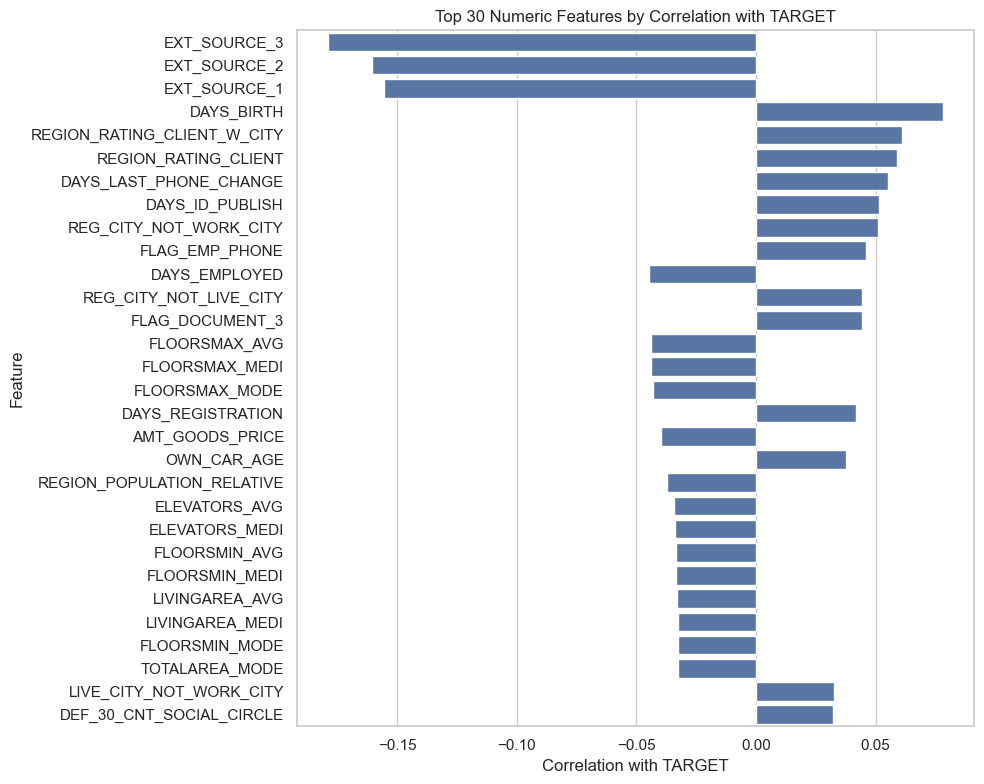

In [26]:
plt.figure(figsize=(10, 8))

top_corr = target_corr.head(30)

sns.barplot(
    x=top_corr.values,
    y=top_corr.index,
)

plt.title("Top 30 Numeric Features by Correlation with TARGET")
plt.xlabel("Correlation with TARGET")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [28]:
target_corr_table.sort_values(
    "correlation_with_target",
    ascending=False,
).head(20)

,feature,correlation_with_target
3,DAYS_BIRTH,0.078239
4,REGION_RATING_CLIENT_W_CITY,0.060893
5,REGION_RATING_CLIENT,0.058899
6,DAYS_LAST_PHONE_CHANGE,0.055218
7,DAYS_ID_PUBLISH,0.051457
8,REG_CITY_NOT_WORK_CITY,0.050994
9,FLAG_EMP_PHONE,0.045982
11,REG_CITY_NOT_LIVE_CITY,0.044395
12,FLAG_DOCUMENT_3,0.044346
16,DAYS_REGISTRATION,0.041975


In [29]:
target_corr_table.sort_values(
    "correlation_with_target",
    ascending=True,
).head(20)

,feature,correlation_with_target
0,EXT_SOURCE_3,-0.178919
1,EXT_SOURCE_2,-0.160472
2,EXT_SOURCE_1,-0.155317
10,DAYS_EMPLOYED,-0.044932
13,FLOORSMAX_AVG,-0.044003
14,FLOORSMAX_MEDI,-0.043768
15,FLOORSMAX_MODE,-0.043226
17,AMT_GOODS_PRICE,-0.039645
19,REGION_POPULATION_RELATIVE,-0.037227
20,ELEVATORS_AVG,-0.034199


### Correlation observations

Самую заметную связь с `TARGET` показывают признаки `EXT_SOURCE_1`, `EXT_SOURCE_2` и `EXT_SOURCE_3`.

Их корреляция с `TARGET` отрицательная: чем выше значение внешнего скорингового признака, тем ниже вероятность дефолта.

Также заметна связь с возрастом клиента через `DAYS_BIRTH`. Так как `DAYS_BIRTH` хранится отрицательным числом, положительная корреляция означает, что более молодые клиенты чаще имеют `TARGET = 1`.

Региональные признаки `REGION_RATING_CLIENT` и `REGION_RATING_CLIENT_W_CITY` положительно связаны с дефолтом, что может означать более высокий риск для клиентов из регионов с худшим рейтингом.

Часть жилищных признаков также попадает в топ корреляций, но у них высокая доля пропусков, поэтому их нужно обрабатывать осторожно.

Корреляция является только первичной проверкой. Для финального отбора признаков позже нужно использовать IV / WOE, feature importance и SHAP.

## 7. External source features

Признаки `EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3` выглядят как внешние скоринговые оценки клиента.

На предыдущем графике они показали самую сильную отрицательную корреляцию с `TARGET`.

Проверим:

- базовую статистику;
- долю пропусков;
- корреляцию с `TARGET`;
- распределение значений отдельно для `TARGET = 0` и `TARGET = 1`.

In [30]:
ext_source_features = [
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
]

application_train[ext_source_features + ["TARGET"]].describe().T

,count,mean,std,min,25%,50%,75%,max
EXT_SOURCE_1,134133.0,0.502130,0.211062,1.456813e-02,0.334007,0.505998,0.675053,0.962693
EXT_SOURCE_2,306851.0,0.514393,0.191060,8.173617e-08,0.392457,0.565961,0.663617,0.855000
EXT_SOURCE_3,246546.0,0.510853,0.194844,5.272652e-04,0.370650,0.535276,0.669057,0.896010
TARGET,307511.0,0.080729,0.272419,0.000000e+00,0.000000,0.000000,0.000000,1.000000


In [31]:
ext_source_missing = pd.DataFrame(
    {
        "missing_count": application_train[ext_source_features].isna().sum(),
        "missing_rate": application_train[ext_source_features].isna().mean(),
    }
).sort_values("missing_rate", ascending=False)

ext_source_missing

,missing_count,missing_rate
EXT_SOURCE_1,173378,0.563811
EXT_SOURCE_3,60965,0.198253
EXT_SOURCE_2,660,0.002146


In [32]:
application_train.groupby("TARGET")[ext_source_features].mean()

,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
TARGET,,,
0,0.511461,0.523479,0.520969
1,0.386968,0.410935,0.390717


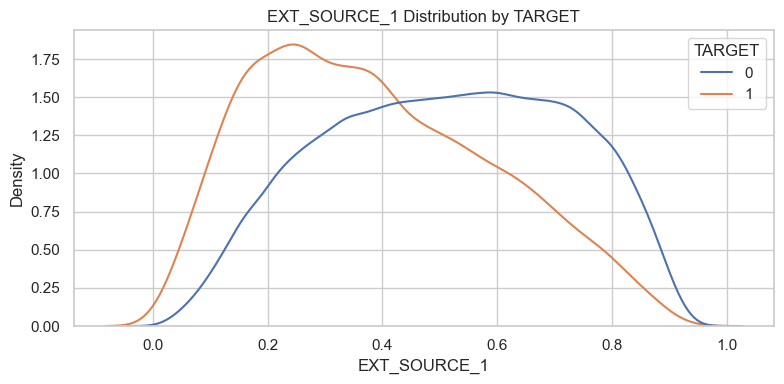

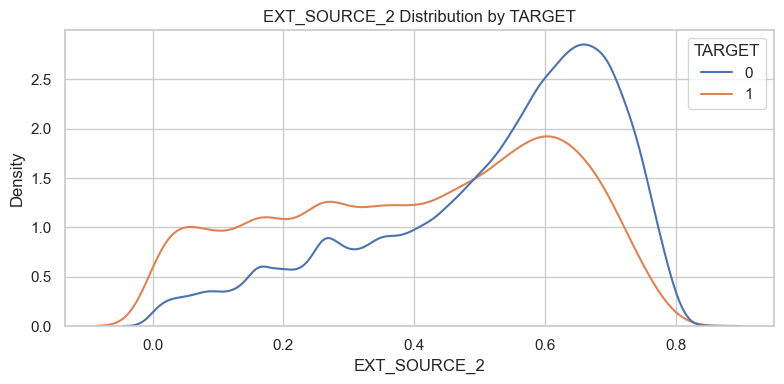

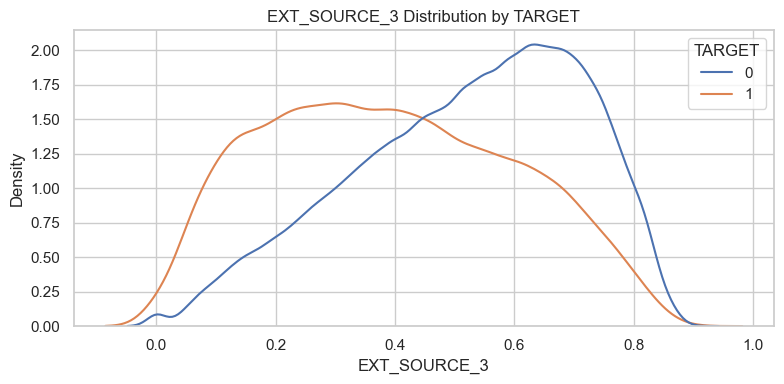

In [33]:
for col in ext_source_features:
    plt.figure(figsize=(8, 4))

    sns.kdeplot(
        data=application_train,
        x=col,
        hue="TARGET",
        common_norm=False,
    )

    plt.title(f"{col} Distribution by TARGET")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

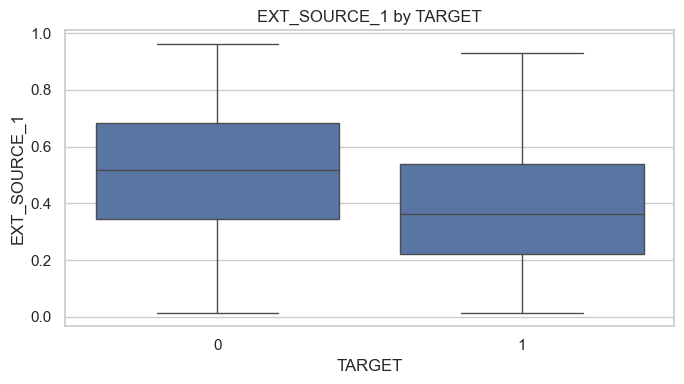

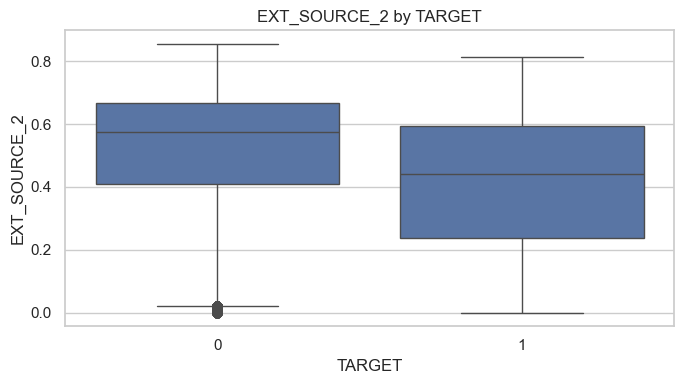

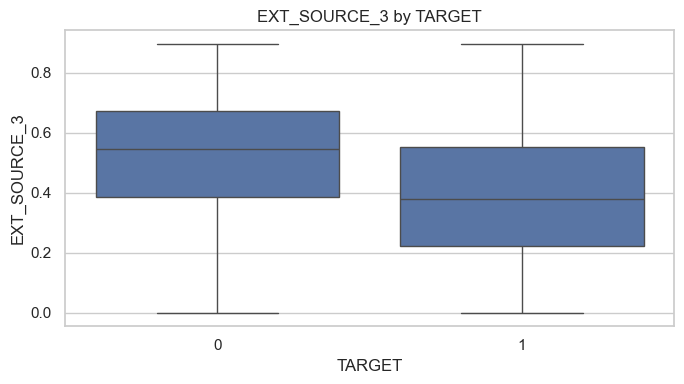

In [34]:
for col in ext_source_features:
    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=application_train,
        x="TARGET",
        y=col,
    )

    plt.title(f"{col} by TARGET")
    plt.xlabel("TARGET")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

In [35]:
ext_source_corr = (
    application_train[ext_source_features + ["TARGET"]]
    .corr(numeric_only=True)["TARGET"]
    .drop("TARGET")
    .sort_values()
    .to_frame("correlation_with_target")
)

ext_source_corr

,correlation_with_target
EXT_SOURCE_3,-0.178919
EXT_SOURCE_2,-0.160472
EXT_SOURCE_1,-0.155317


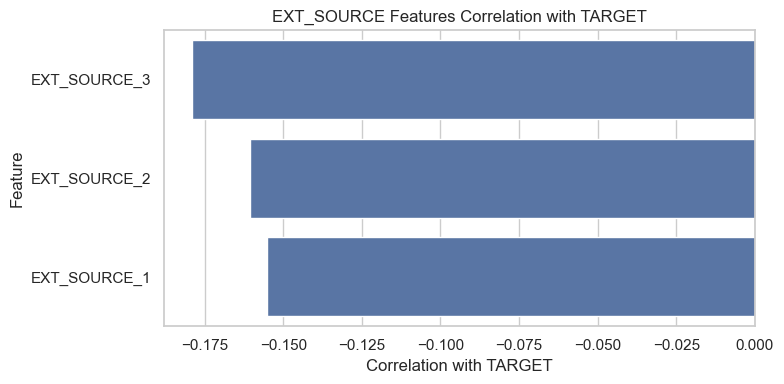

In [36]:
plt.figure(figsize=(8, 4))

sns.barplot(
    data=ext_source_corr.reset_index(),
    x="correlation_with_target",
    y="index",
)

plt.title("EXT_SOURCE Features Correlation with TARGET")
plt.xlabel("Correlation with TARGET")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### External source features observations

`EXT_SOURCE_1`, `EXT_SOURCE_2` и `EXT_SOURCE_3` имеют отрицательную связь с `TARGET`.

Это означает, что чем выше значение внешнего скорингового признака, тем ниже вероятность дефолта клиента.

По средним значениям видно, что у клиентов без дефолта (`TARGET = 0`) значения `EXT_SOURCE_*` заметно выше, чем у клиентов с дефолтом (`TARGET = 1`):

- для `TARGET = 0` средние значения находятся примерно в диапазоне `0.51–0.52`;
- для `TARGET = 1` средние значения ниже — примерно `0.39–0.41`.

Распределения также подтверждают эту идею: клиенты с `TARGET = 1` чаще находятся в области более низких значений `EXT_SOURCE_*`.

При этом у признаков разная доля пропусков:

- `EXT_SOURCE_1` имеет очень много пропусков — около 56%;
- `EXT_SOURCE_3` имеет около 20% пропусков;
- `EXT_SOURCE_2` почти полностью заполнен.

Эти признаки выглядят очень важными для модели, но пропуски нужно будет аккуратно обработать на этапе preprocessing / feature engineering.

## 8. Amount features

Рассмотрим основные денежные признаки заявки:

- `AMT_INCOME_TOTAL` — доход клиента;
- `AMT_CREDIT` — сумма кредита;
- `AMT_ANNUITY` — ежегодный платёж;
- `AMT_GOODS_PRICE` — цена товара.

Проверим:

- базовую статистику;
- пропуски;
- распределения;
- различия между `TARGET = 0` и `TARGET = 1`;
- наличие выбросов.

In [37]:
amount_features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
]

application_train[amount_features + ["TARGET"]].describe().T

,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1615.5,16524.0,24903.0,34596.0,258025.5
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,40500.0,238500.0,450000.0,679500.0,4050000.0
TARGET,307511.0,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0


In [38]:
amount_missing = pd.DataFrame(
    {
        "missing_count": application_train[amount_features].isna().sum(),
        "missing_rate": application_train[amount_features].isna().mean(),
    }
).sort_values("missing_rate", ascending=False)

amount_missing

,missing_count,missing_rate
AMT_GOODS_PRICE,278,0.000904
AMT_ANNUITY,12,0.000039
AMT_INCOME_TOTAL,0,0.000000
AMT_CREDIT,0,0.000000


In [39]:
application_train.groupby("TARGET")[amount_features].agg(["mean", "median"])

AMT_INCOME_TOTAL               AMT_CREDIT             AMT_ANNUITY  \
                   mean    median           mean    median          mean   
TARGET                                                                     
0         169077.722266  148500.0  602648.282002  517788.0  27163.623349   
1         165611.760906  135000.0  557778.527674  497520.0  26481.744290   

                AMT_GOODS_PRICE            
         median            mean    median  
TARGET                                     
0       24876.0   542736.795003  450000.0  
1       25263.0   488972.412554  450000.0

In [40]:
amount_corr = (
    application_train[amount_features + ["TARGET"]]
    .corr(numeric_only=True)["TARGET"]
    .drop("TARGET")
    .sort_values()
    .to_frame("correlation_with_target")
)

amount_corr

,correlation_with_target
AMT_GOODS_PRICE,-0.039645
AMT_CREDIT,-0.030369
AMT_ANNUITY,-0.012817
AMT_INCOME_TOTAL,-0.003982


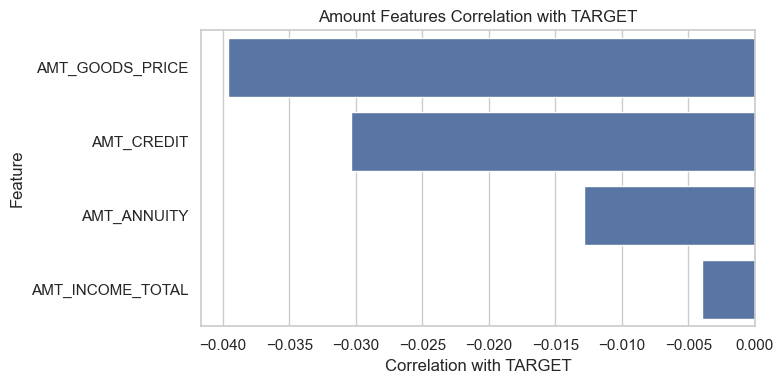

In [41]:
plt.figure(figsize=(8, 4))

sns.barplot(
    data=amount_corr.reset_index(),
    x="correlation_with_target",
    y="index",
)

plt.title("Amount Features Correlation with TARGET")
plt.xlabel("Correlation with TARGET")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

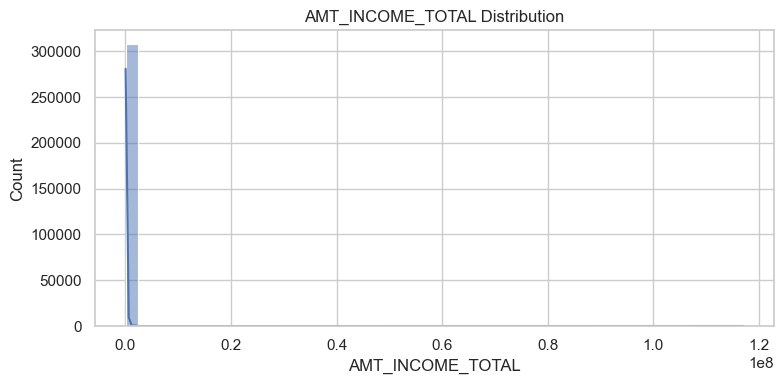

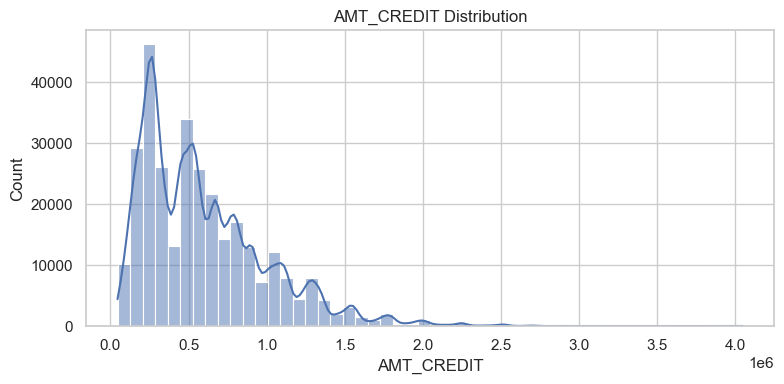

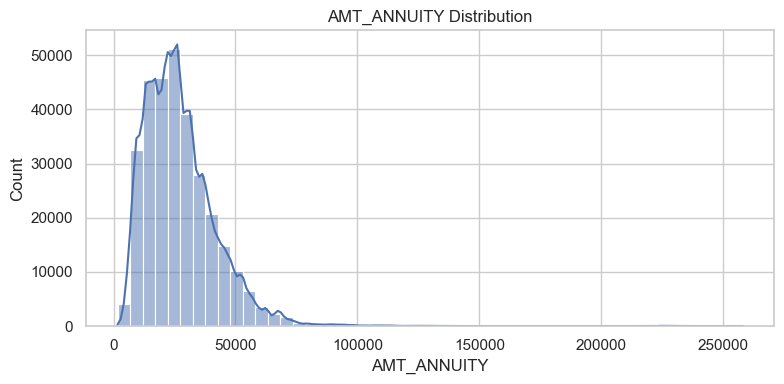

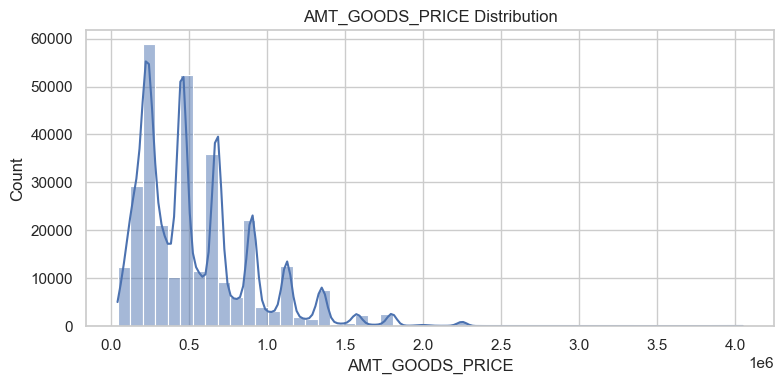

In [42]:
for col in amount_features:
    plt.figure(figsize=(8, 4))

    sns.histplot(
        data=application_train,
        x=col,
        bins=50,
        kde=True,
    )

    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

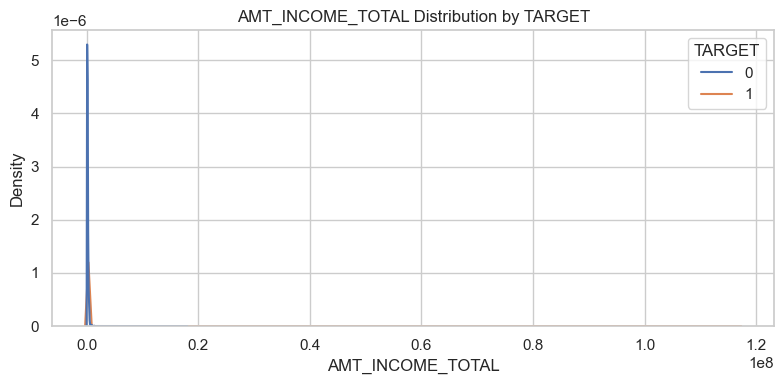

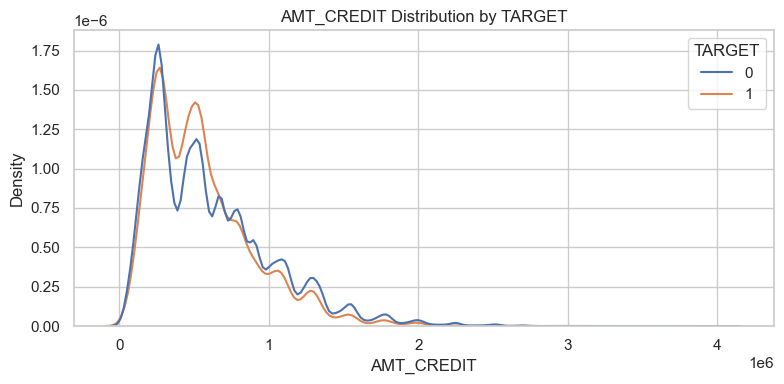

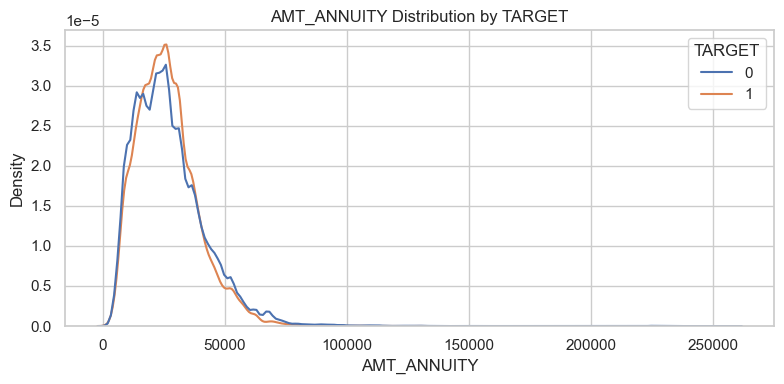

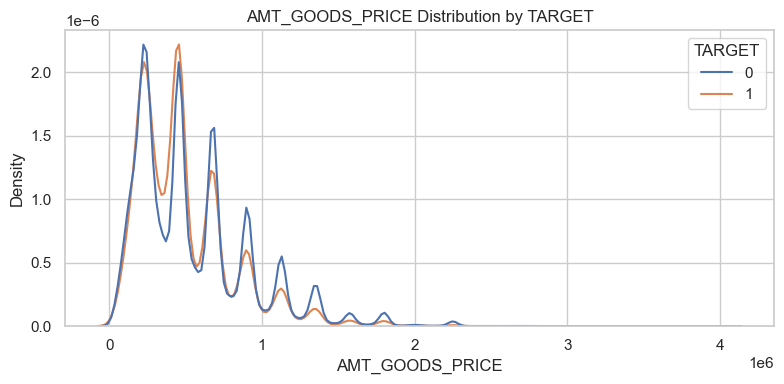

In [43]:
for col in amount_features:
    plt.figure(figsize=(8, 4))

    sns.kdeplot(
        data=application_train,
        x=col,
        hue="TARGET",
        common_norm=False,
    )

    plt.title(f"{col} Distribution by TARGET")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

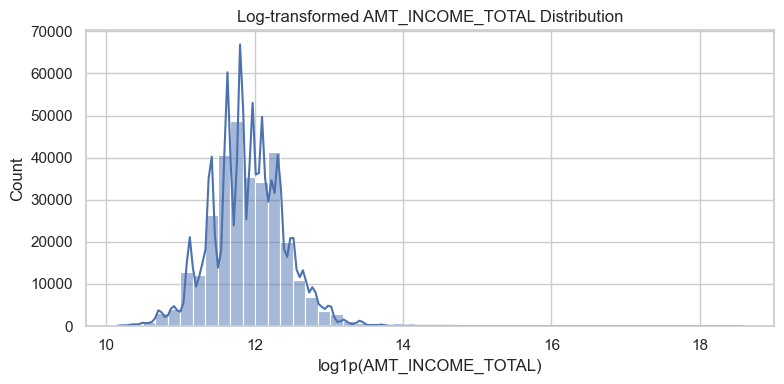

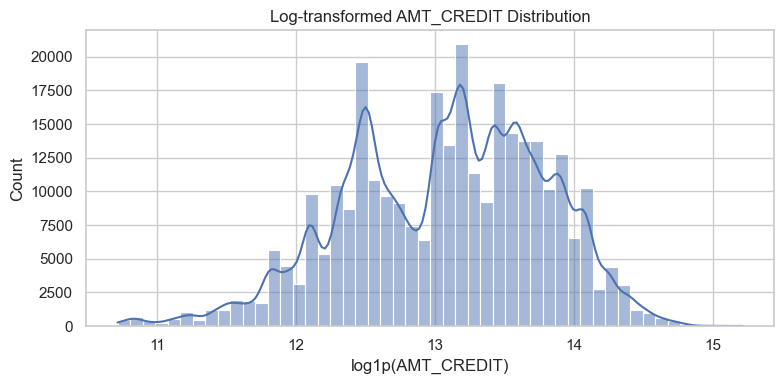

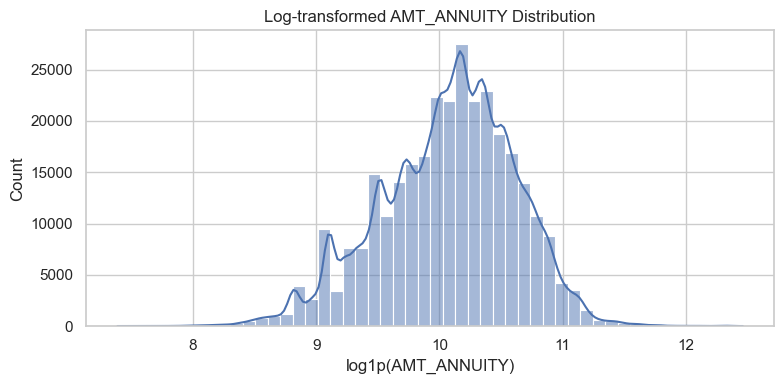

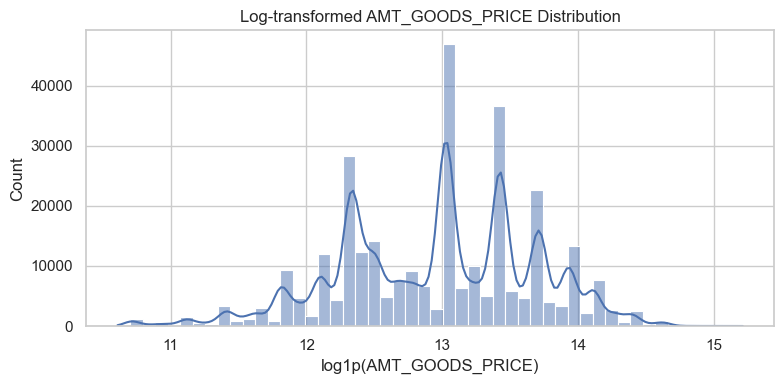

In [44]:
for col in amount_features:
    plt.figure(figsize=(8, 4))

    sns.histplot(
        data=np.log1p(application_train[col]),
        bins=50,
        kde=True,
    )

    plt.title(f"Log-transformed {col} Distribution")
    plt.xlabel(f"log1p({col})")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

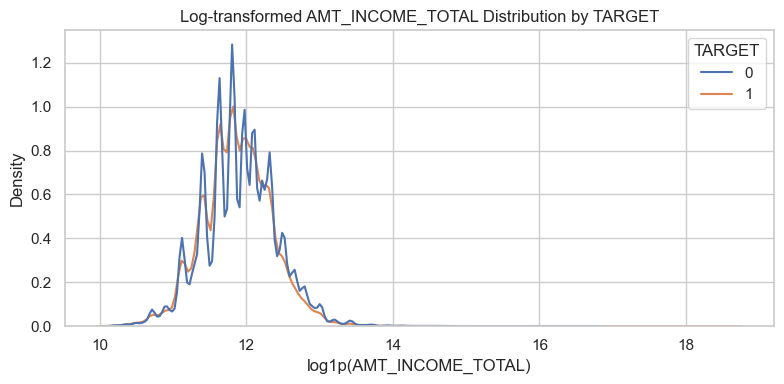

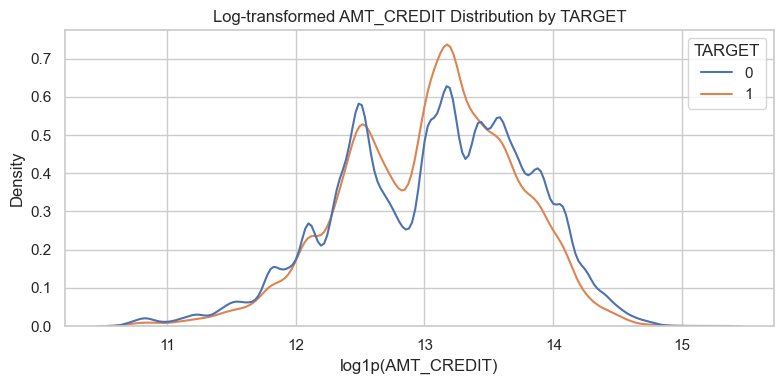

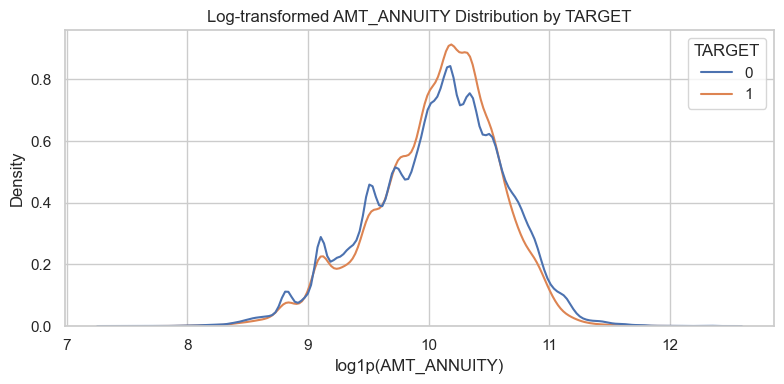

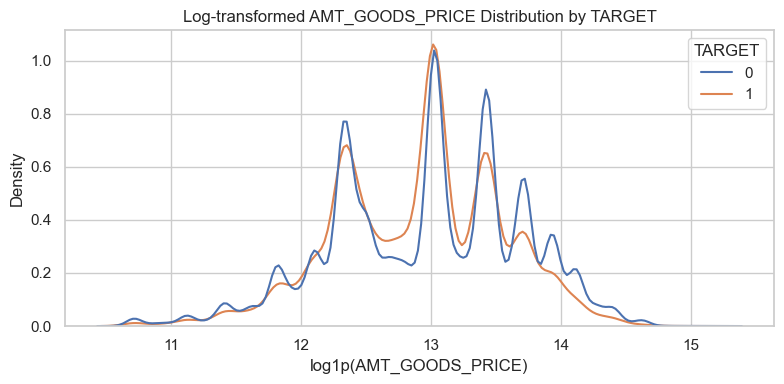

In [45]:
for col in amount_features:
    plt.figure(figsize=(8, 4))

    sns.kdeplot(
        x=np.log1p(application_train[col]),
        hue=application_train["TARGET"],
        common_norm=False,
    )

    plt.title(f"Log-transformed {col} Distribution by TARGET")
    plt.xlabel(f"log1p({col})")
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

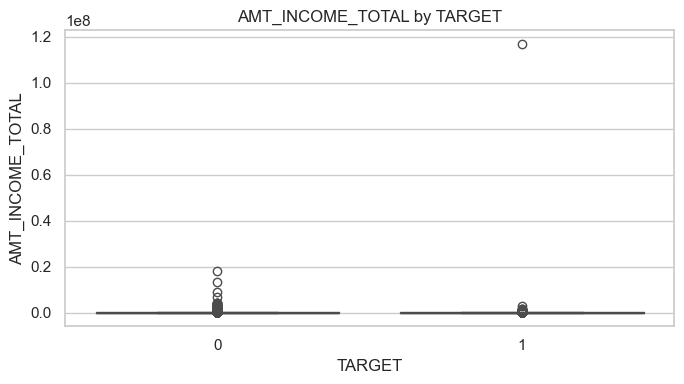

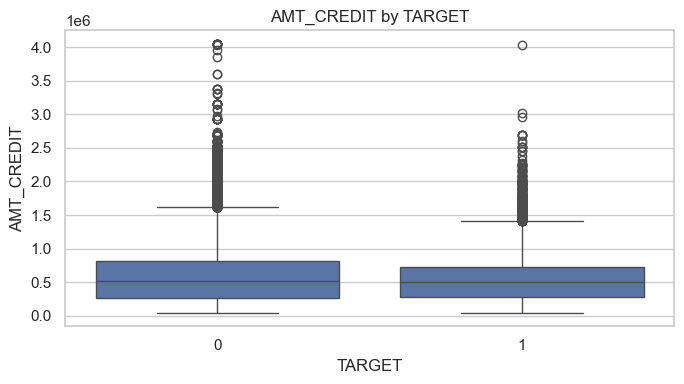

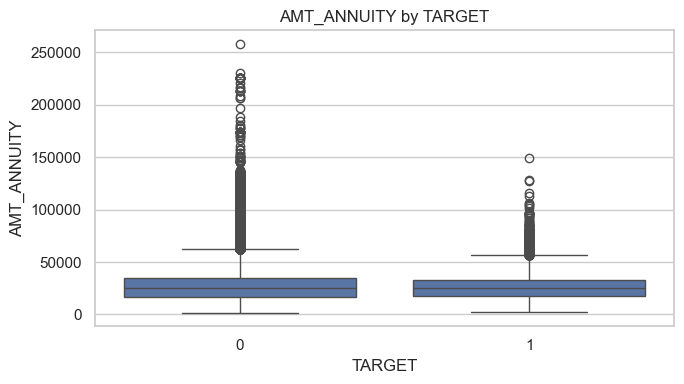

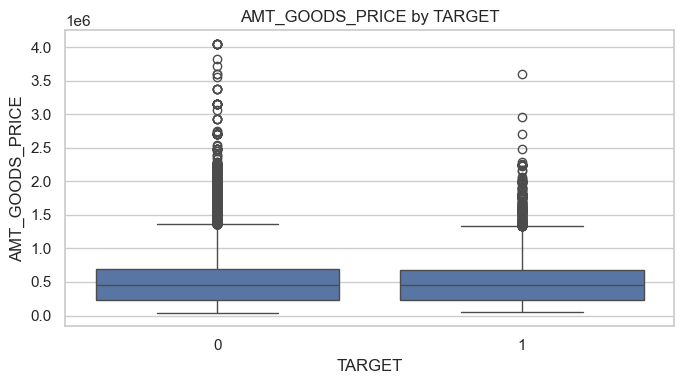

In [46]:
for col in amount_features:
    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=application_train,
        x="TARGET",
        y=col,
    )

    plt.title(f"{col} by TARGET")
    plt.xlabel("TARGET")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

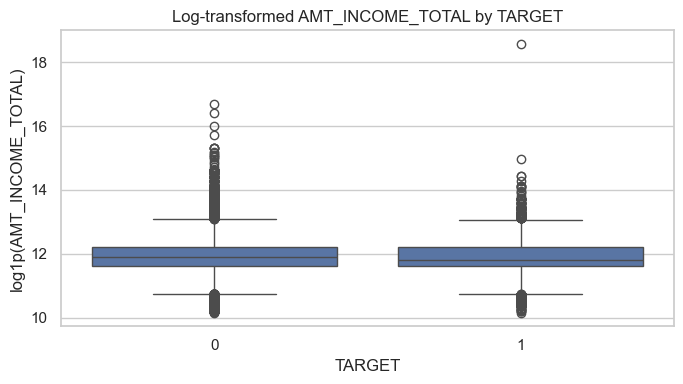

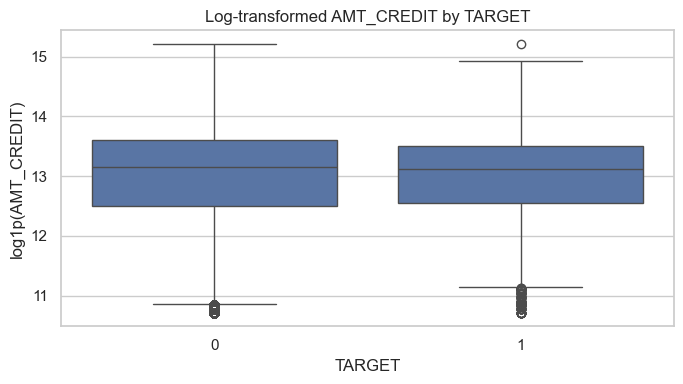

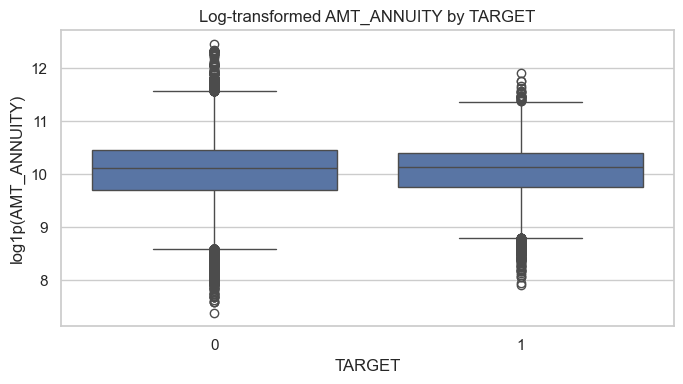

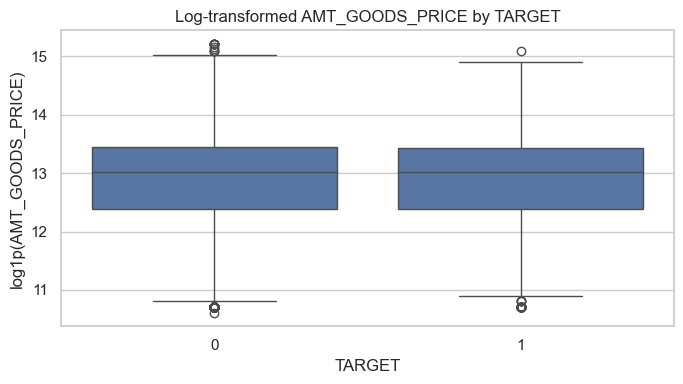

In [47]:
for col in amount_features:
    plt.figure(figsize=(7, 4))

    sns.boxplot(
        x=application_train["TARGET"],
        y=np.log1p(application_train[col]),
    )

    plt.title(f"Log-transformed {col} by TARGET")
    plt.xlabel("TARGET")
    plt.ylabel(f"log1p({col})")
    plt.tight_layout()
    plt.show()

### Amount features observations

Денежные признаки имеют сильно скошенные распределения и заметные выбросы. Особенно это видно у `AMT_INCOME_TOTAL`: максимальное значение значительно выше медианы, поэтому среднее значение может быть искажено редкими крупными доходами.

Пропусков в денежных признаках почти нет. `AMT_INCOME_TOTAL` и `AMT_CREDIT` не имеют пропусков, а в `AMT_ANNUITY` и `AMT_GOODS_PRICE` доля пропущенных значений очень мала.

Корреляция денежных признаков с `TARGET` слабая. Наиболее заметная отрицательная связь наблюдается у `AMT_GOODS_PRICE` и `AMT_CREDIT`, но по абсолютному значению она небольшая. Это означает, что сами по себе абсолютные суммы кредита, дохода или платежа не являются сильными линейными предикторами дефолта.

При сравнении групп `TARGET = 0` и `TARGET = 1` видно, что у клиентов с дефолтом в среднем немного ниже доход, сумма кредита и стоимость товара. Однако различия не настолько сильные, как у признаков `EXT_SOURCE`.

Основной вывод: денежные признаки стоит оставить в данных, но более информативными могут быть не сами абсолютные суммы, а отношения между ними, например сумма кредита к доходу или аннуитетный платеж к доходу. Поэтому дальше создадим и проанализируем ratio-признаки.

## 9. Ratio features

Абсолютные денежные признаки не всегда хорошо отражают финансовую нагрузку клиента.

Например, один и тот же кредит может быть небольшим для клиента с высоким доходом и слишком большим для клиента с низким доходом.

Поэтому создадим признаки-отношения:

- `CREDIT_INCOME_RATIO` — отношение суммы кредита к доходу клиента;
- `ANNUITY_INCOME_RATIO` — отношение аннуитетного платежа к доходу клиента;
- `ANNUITY_CREDIT_RATIO` — отношение аннуитетного платежа к сумме кредита;
- `GOODS_CREDIT_RATIO` — отношение стоимости товара к сумме кредита.

In [58]:
ratio_features = [
    "CREDIT_INCOME_RATIO", # во сколько раз сумма кредита больше годового дохода клиента
    "ANNUITY_INCOME_RATIO", # какая часть дохода уходит на аннуитетный платёж
    "ANNUITY_CREDIT_RATIO", # размер регулярного платежа относительно всей суммы кредита
    "GOODS_CREDIT_RATIO", # отношение стоимости товара к сумме кредита
]

application_train = application_train.drop(
    columns=[col for col in ratio_features if col in application_train.columns]
)

ratio_features_df = pd.DataFrame(
    {
        "CREDIT_INCOME_RATIO": application_train["AMT_CREDIT"] / application_train["AMT_INCOME_TOTAL"],
        "ANNUITY_INCOME_RATIO": application_train["AMT_ANNUITY"] / application_train["AMT_INCOME_TOTAL"],
        "ANNUITY_CREDIT_RATIO": application_train["AMT_ANNUITY"] / application_train["AMT_CREDIT"],
        "GOODS_CREDIT_RATIO": application_train["AMT_GOODS_PRICE"] / application_train["AMT_CREDIT"],
    },
    index=application_train.index,
)

ratio_features_df = ratio_features_df.replace([np.inf, -np.inf], np.nan)

application_train = pd.concat([application_train, ratio_features_df], axis=1).copy()

application_train[ratio_features + ["TARGET"]].describe().T

,count,mean,std,min,25%,50%,75%,max
CREDIT_INCOME_RATIO,307511.0,3.957570,2.689728,0.004808,2.018667,3.265067,5.159880,84.736842
ANNUITY_INCOME_RATIO,307499.0,0.180930,0.094574,0.000224,0.114782,0.162833,0.229067,1.875965
ANNUITY_CREDIT_RATIO,307499.0,0.053695,0.022481,0.022073,0.036900,0.050000,0.064043,0.124430
GOODS_CREDIT_RATIO,307233.0,0.900689,0.096630,0.166667,0.834725,0.893815,1.000000,6.666667
TARGET,307511.0,0.080729,0.272419,0.000000,0.000000,0.000000,0.000000,1.000000


In [59]:
ratio_missing = pd.DataFrame(
    {
        "missing_count": application_train[ratio_features].isna().sum(),
        "missing_rate": application_train[ratio_features].isna().mean(),
    }
).sort_values("missing_rate", ascending=False)

ratio_missing

,missing_count,missing_rate
GOODS_CREDIT_RATIO,278,0.000904
ANNUITY_INCOME_RATIO,12,0.000039
ANNUITY_CREDIT_RATIO,12,0.000039
CREDIT_INCOME_RATIO,0,0.000000


In [60]:
application_train.groupby("TARGET")[ratio_features].agg(["mean", "median"])

CREDIT_INCOME_RATIO           ANNUITY_INCOME_RATIO            \
                      mean    median                 mean    median   
TARGET                                                                
0                 3.963729  3.266653             0.180530  0.162280   
1                 3.887438  3.253143             0.185482  0.169294   

       ANNUITY_CREDIT_RATIO        GOODS_CREDIT_RATIO            
                       mean median               mean    median  
TARGET                                                           
0                  0.053610   0.05           0.902562  0.893815  
1                  0.054659   0.05           0.879362  0.873210

In [61]:
ratio_corr = (
    application_train[ratio_features + ["TARGET"]]
    .corr(numeric_only=True)["TARGET"]
    .drop("TARGET")
    .sort_values()
    .to_frame("correlation_with_target")
)

ratio_corr

,correlation_with_target
GOODS_CREDIT_RATIO,-0.065407
CREDIT_INCOME_RATIO,-0.007727
ANNUITY_CREDIT_RATIO,0.012704
ANNUITY_INCOME_RATIO,0.014265


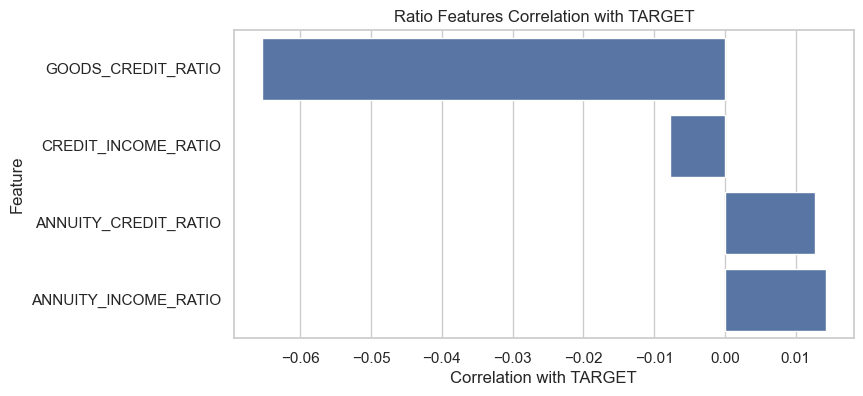

In [62]:
plt.figure(figsize=(8, 4))

sns.barplot(
    data=ratio_corr.reset_index(),
    x="correlation_with_target",
    y="index",
)

plt.title("Ratio Features Correlation with TARGET")
plt.xlabel("Correlation with TARGET")
plt.ylabel("Feature")

plt.show()

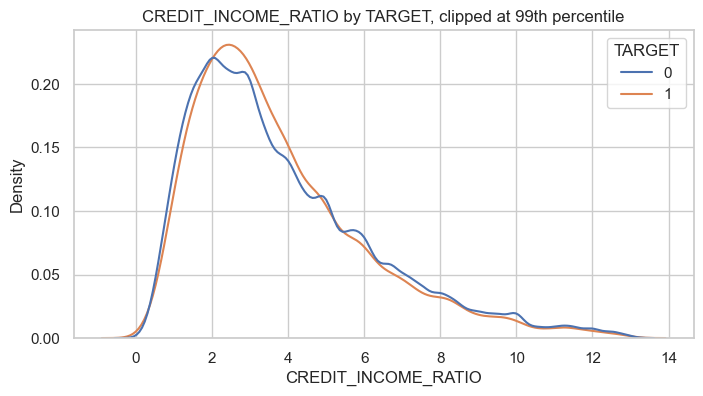

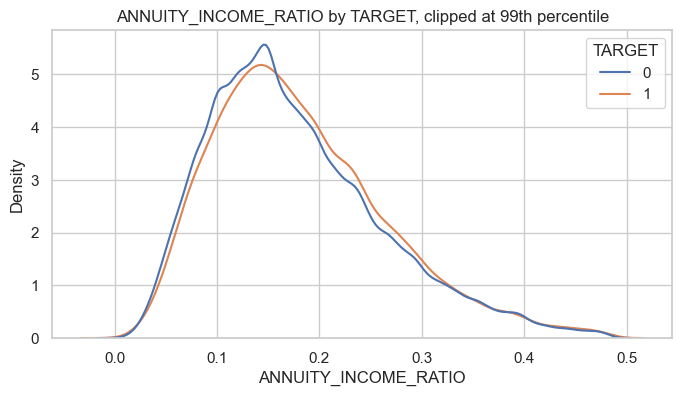

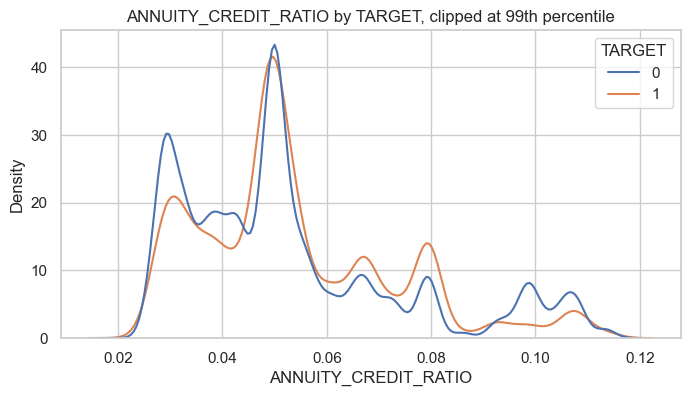

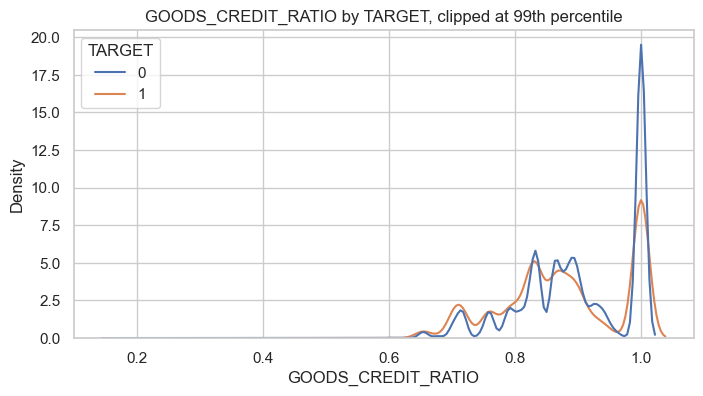

In [63]:
for col in ratio_features:
    data_plot = application_train[[col, "TARGET"]].copy()
    data_plot = data_plot.replace([np.inf, -np.inf], np.nan).dropna()

    upper_limit = data_plot[col].quantile(0.99)
    data_plot = data_plot[data_plot[col] <= upper_limit]

    plt.figure(figsize=(8, 4))

    sns.kdeplot(
        data=data_plot,
        x=col,
        hue="TARGET",
        common_norm=False,
    )

    plt.title(f"{col} by TARGET, clipped at 99th percentile")
    plt.xlabel(col)
    plt.ylabel("Density")

    plt.show()

### Ratio features observations

В этом разделе были созданы ratio-признаки, которые отражают финансовую нагрузку клиента относительно его дохода и суммы кредита.

`CREDIT_INCOME_RATIO` показывает отношение суммы кредита к доходу клиента. В среднем сумма кредита примерно в 4 раза больше дохода клиента, при этом распределение имеет заметные выбросы.

`ANNUITY_INCOME_RATIO` показывает долю дохода, которая приходится на аннуитетный платёж. У клиентов с `TARGET = 1` медианное значение этого признака немного выше, чем у клиентов с `TARGET = 0`, что может указывать на более высокую платёжную нагрузку у дефолтных клиентов.

Корреляция ratio-признаков с `TARGET` в целом слабая. Наиболее заметную связь показывает `GOODS_CREDIT_RATIO`, однако даже она остаётся небольшой по абсолютному значению.

KDE-графики показывают, что распределения для `TARGET = 0` и `TARGET = 1` сильно пересекаются. Это означает, что ratio-признаки сами по себе плохо разделяют дефолтных и недефолтных клиентов.

Основной вывод: ratio-признаки имеют хороший бизнес-смысл и могут быть полезны модели в комбинации с другими признаками, но не являются сильными самостоятельными предикторами дефолта.

## 10. Age and DAYS features

В датасете есть несколько признаков, связанных с возрастом клиента, стажем работы, регистрацией и изменением документов.

Особенность этих признаков в том, что они записаны в днях и обычно имеют отрицательные значения, потому что считаются относительно даты подачи заявки.

Например:

- `DAYS_BIRTH` — возраст клиента в днях;
- `DAYS_EMPLOYED` — сколько дней клиент работает;
- `DAYS_REGISTRATION` — сколько дней прошло с момента регистрации;
- `DAYS_ID_PUBLISH` — сколько дней прошло с момента выдачи/изменения документа.

Для удобной интерпретации переведём часть признаков в годы и проверим их связь с `TARGET`.

In [64]:
days_features = [
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "DAYS_REGISTRATION",
    "DAYS_ID_PUBLISH",
]

application_train[days_features].describe().T

,count,mean,std,min,25%,50%,75%,max
DAYS_BIRTH,307511.0,-16036.995067,4363.988632,-25229.0,-19682.0,-15750.0,-12413.0,-7489.0
DAYS_EMPLOYED,307511.0,63815.045904,141275.766519,-17912.0,-2760.0,-1213.0,-289.0,365243.0
DAYS_REGISTRATION,307511.0,-4986.120328,3522.886321,-24672.0,-7479.5,-4504.0,-2010.0,0.0
DAYS_ID_PUBLISH,307511.0,-2994.202373,1509.450419,-7197.0,-4299.0,-3254.0,-1720.0,0.0


In [65]:
days_missing = pd.DataFrame(
    {
        "missing_count": application_train[days_features].isna().sum(),
        "missing_rate": application_train[days_features].isna().mean(),
    }
).sort_values("missing_rate", ascending=False)

days_missing

,missing_count,missing_rate
DAYS_BIRTH,0,0.0
DAYS_EMPLOYED,0,0.0
DAYS_REGISTRATION,0,0.0
DAYS_ID_PUBLISH,0,0.0


In [66]:
application_train["DAYS_EMPLOYED"].value_counts().head()
# скорее всего число 365243 - это код особого стажа работы, поэтому эти аномалии будем пропускать иначе сломаем статистику

DAYS_EMPLOYED
 365243    55374
-200         156
-224         152
-199         151
-230         151
Name: count, dtype: int64

In [67]:
(application_train["DAYS_EMPLOYED"] == 365243).mean()

np.float64(0.18007160719453938)

In [69]:
application_train["AGE_YEARS"] = -application_train["DAYS_BIRTH"] / 365

application_train["DAYS_EMPLOYED_ANOMALY"] = (
    application_train["DAYS_EMPLOYED"] == 365243
).astype(int)

application_train["DAYS_EMPLOYED_CLEAN"] = application_train["DAYS_EMPLOYED"].replace(
    365243, np.nan
)

application_train["EMPLOYED_YEARS"] = -application_train["DAYS_EMPLOYED_CLEAN"] / 365
application_train["REGISTRATION_YEARS"] = -application_train["DAYS_REGISTRATION"] / 365
application_train["ID_PUBLISH_YEARS"] = -application_train["DAYS_ID_PUBLISH"] / 365

age_days_features = [
    "AGE_YEARS",
    "EMPLOYED_YEARS",
    "REGISTRATION_YEARS",
    "ID_PUBLISH_YEARS",
    "DAYS_EMPLOYED_ANOMALY",
]

application_train[age_days_features].describe().T

,count,mean,std,min,25%,50%,75%,max
AGE_YEARS,307511.0,43.936973,11.956133,20.517808,34.008219,43.150685,53.923288,69.120548
EMPLOYED_YEARS,252137.0,6.531971,6.406466,-0.000000,2.101370,4.515068,8.698630,49.073973
REGISTRATION_YEARS,307511.0,13.660604,9.651743,-0.000000,5.506849,12.339726,20.491781,67.594521
ID_PUBLISH_YEARS,307511.0,8.203294,4.135481,0.000000,4.712329,8.915068,11.778082,19.717808
DAYS_EMPLOYED_ANOMALY,307511.0,0.180072,0.384248,0.000000,0.000000,0.000000,0.000000,1.000000


In [70]:
application_train.groupby("TARGET")[age_days_features].agg(["mean", "median"])

AGE_YEARS            EMPLOYED_YEARS           REGISTRATION_YEARS  \
             mean     median           mean    median               mean   
TARGET                                                                     
0       44.214182  43.498630       6.679836  4.632877          13.780660   
1       40.780351  39.128767       4.972380  3.369863          12.293499   

                  ID_PUBLISH_YEARS           DAYS_EMPLOYED_ANOMALY         
           median             mean    median                  mean median  
TARGET                                                                     
0       12.449315         8.266356  9.027397              0.185308    0.0  
1       11.112329         7.485204  7.663014              0.120443    0.0

In [71]:
age_days_corr = (
    application_train[age_days_features + ["TARGET"]]
    .corr(numeric_only=True)["TARGET"]
    .drop("TARGET")
    .sort_values()
    .to_frame("correlation_with_target")
)

age_days_corr

,correlation_with_target
AGE_YEARS,-0.078239
EMPLOYED_YEARS,-0.074958
ID_PUBLISH_YEARS,-0.051457
DAYS_EMPLOYED_ANOMALY,-0.045987
REGISTRATION_YEARS,-0.041975


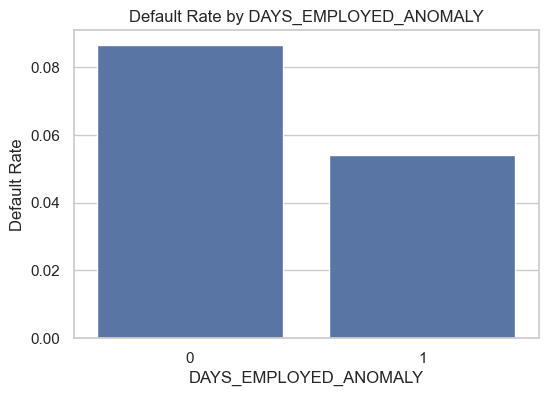

In [72]:
anomaly_target_rate = (
    application_train
    .groupby("DAYS_EMPLOYED_ANOMALY")["TARGET"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6, 4))

sns.barplot(
    data=anomaly_target_rate,
    x="DAYS_EMPLOYED_ANOMALY",
    y="TARGET",
)

plt.title("Default Rate by DAYS_EMPLOYED_ANOMALY")
plt.xlabel("DAYS_EMPLOYED_ANOMALY")
plt.ylabel("Default Rate")

plt.show()

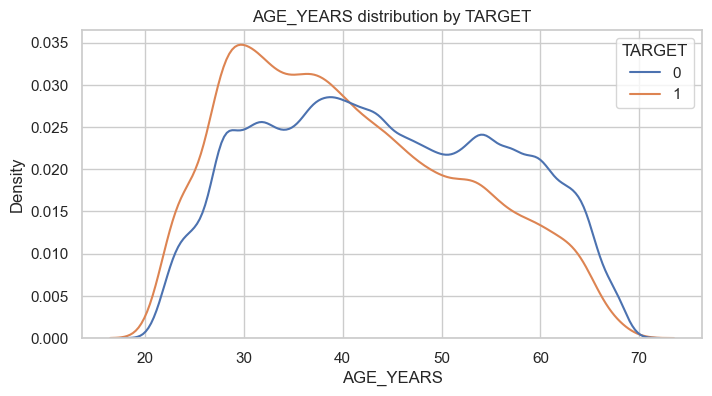

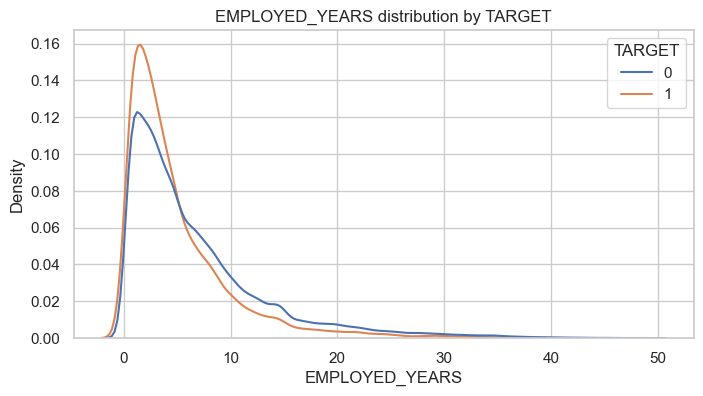

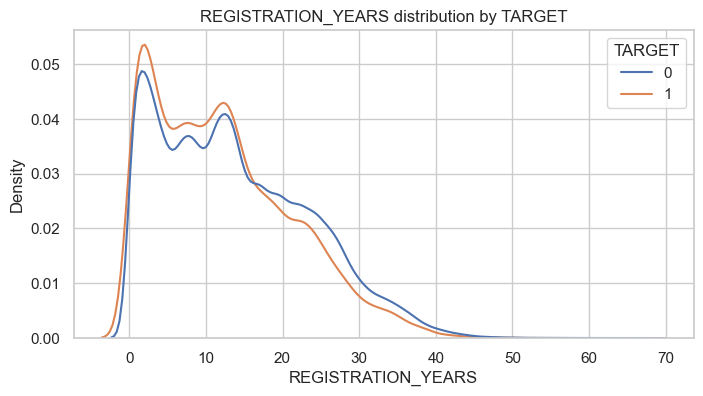

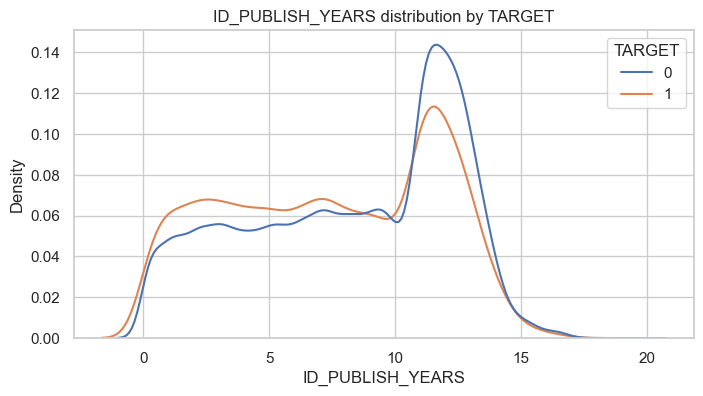

In [73]:
continuous_age_days_features = [
    "AGE_YEARS",
    "EMPLOYED_YEARS",
    "REGISTRATION_YEARS",
    "ID_PUBLISH_YEARS",
]

for col in continuous_age_days_features:
    data_plot = application_train[[col, "TARGET"]].replace([np.inf, -np.inf], np.nan).dropna()

    plt.figure(figsize=(8, 4))

    sns.kdeplot(
        data=data_plot,
        x=col,
        hue="TARGET",
        common_norm=False,
    )

    plt.title(f"{col} distribution by TARGET")
    plt.xlabel(col)
    plt.ylabel("Density")

    plt.show()

### Age and DAYS features observations

В этом разделе были рассмотрены признаки, связанные с возрастом клиента, стажем работы, регистрацией и датой выдачи документа.

Исходные признаки `DAYS_BIRTH`, `DAYS_EMPLOYED`, `DAYS_REGISTRATION` и `DAYS_ID_PUBLISH` представлены в днях относительно даты подачи заявки. Для удобства интерпретации они были преобразованы в годы.

В признаке `DAYS_EMPLOYED` было найдено аномальное значение `365243`. Такое значение не может отражать реальный трудовой стаж, так как соответствует примерно 1000 годам. Поэтому оно было заменено на пропуск в очищенной версии признака, а также был создан отдельный бинарный признак `DAYS_EMPLOYED_ANOMALY`, который фиксирует наличие этой аномалии.

Распределение `AGE_YEARS` показывает заметные различия между группами `TARGET = 0` и `TARGET = 1`. Клиенты с дефолтом чаще представлены в более молодых возрастных группах, примерно от 25 до 40 лет. У клиентов без дефолта распределение сильнее смещено в сторону более старшего возраста.

Это говорит о том, что возраст клиента связан с кредитным риском: более молодые клиенты в данном датасете чаще попадают в дефолт, а более взрослые клиенты чаще относятся к группе `TARGET = 0`.

Признаки, связанные со стажем, регистрацией и документами, также могут содержать полезную информацию о стабильности клиента. Их стоит сохранить для дальнейшего моделирования, а аномалию в `DAYS_EMPLOYED` необходимо учитывать отдельно.

## 11. Categorical features and default rates

В этом разделе рассмотрим категориальные признаки.

Для таких признаков нельзя просто смотреть среднее значение, как для числовых переменных. Вместо этого будем анализировать:

- количество уникальных категорий;
- самые частые значения;
- долю дефолтов внутри каждой категории;
- различия между категориями по `TARGET`.

Это поможет понять, какие категории клиентов имеют более высокий или более низкий уровень кредитного риска.

In [75]:
categorical_features = application_train.select_dtypes(
    include=["object", "string"]
).columns.tolist()

len(categorical_features), categorical_features

(16,
 ['NAME_CONTRACT_TYPE',
  'CODE_GENDER',
  'FLAG_OWN_CAR',
  'FLAG_OWN_REALTY',
  'NAME_TYPE_SUITE',
  'NAME_INCOME_TYPE',
  'NAME_EDUCATION_TYPE',
  'NAME_FAMILY_STATUS',
  'NAME_HOUSING_TYPE',
  'OCCUPATION_TYPE',
  'WEEKDAY_APPR_PROCESS_START',
  'ORGANIZATION_TYPE',
  'FONDKAPREMONT_MODE',
  'HOUSETYPE_MODE',
  'WALLSMATERIAL_MODE',
  'EMERGENCYSTATE_MODE'])

In [76]:
categorical_summary = pd.DataFrame(
    {
        "unique_count": application_train[categorical_features].nunique(),
        "missing_count": application_train[categorical_features].isna().sum(),
        "missing_rate": application_train[categorical_features].isna().mean(),
    }
).sort_values("unique_count", ascending=False)

categorical_summary

,unique_count,missing_count,missing_rate
ORGANIZATION_TYPE,58,0,0.000000
OCCUPATION_TYPE,18,96391,0.313455
NAME_INCOME_TYPE,8,0,0.000000
NAME_TYPE_SUITE,7,1292,0.004201
WEEKDAY_APPR_PROCESS_START,7,0,0.000000
WALLSMATERIAL_MODE,7,156341,0.508408
NAME_FAMILY_STATUS,6,0,0.000000
NAME_HOUSING_TYPE,6,0,0.000000
NAME_EDUCATION_TYPE,5,0,0.000000
FONDKAPREMONT_MODE,4,210295,0.683862


In [77]:
main_categorical_features = [
    "CODE_GENDER",
    "NAME_CONTRACT_TYPE",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "OCCUPATION_TYPE",
    "ORGANIZATION_TYPE",
]

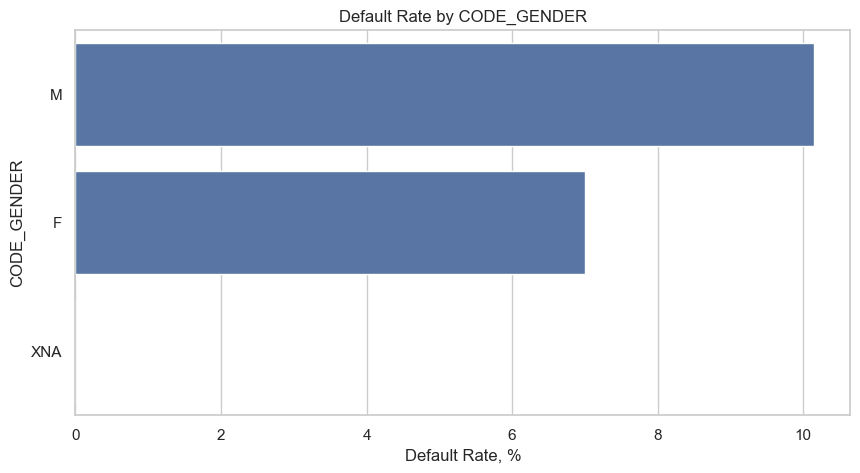

,CODE_GENDER,count,default_rate
0,M,105059,10.141920
1,F,202448,6.999328
2,XNA,4,0.000000


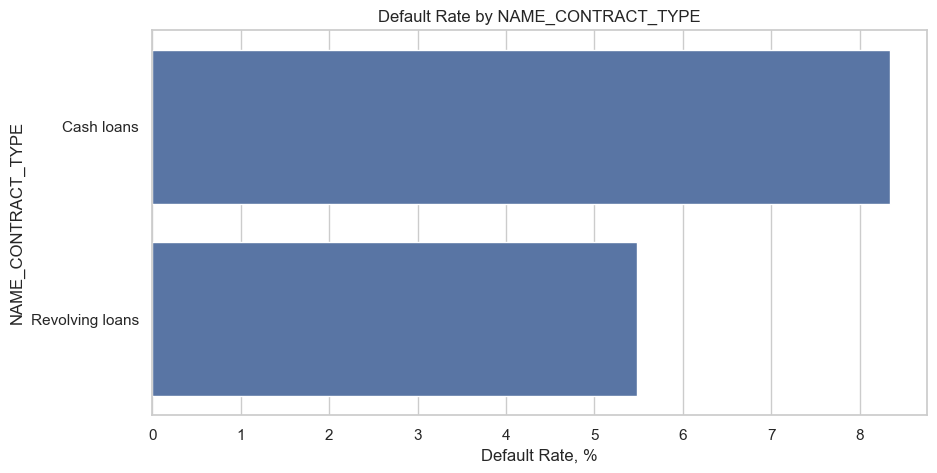

,NAME_CONTRACT_TYPE,count,default_rate
0,Cash loans,278232,8.345913
1,Revolving loans,29279,5.478329


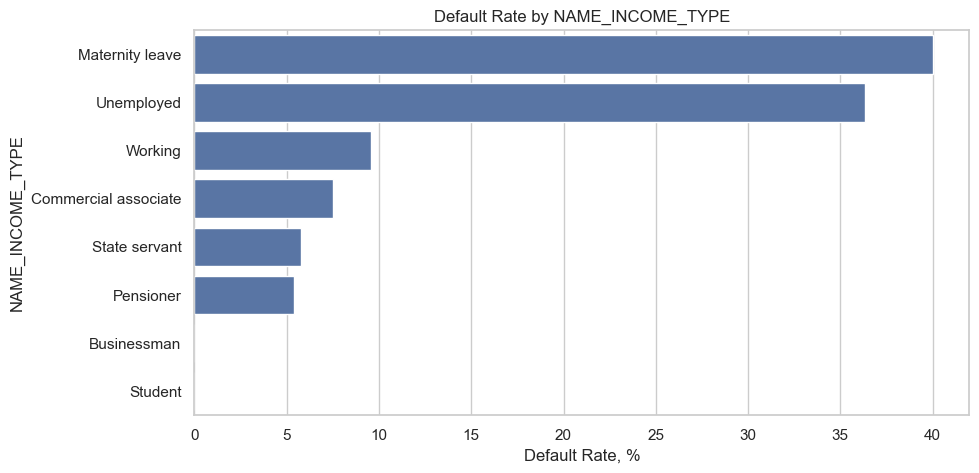

,NAME_INCOME_TYPE,count,default_rate
0,Maternity leave,5,40.000000
1,Unemployed,22,36.363636
2,Working,158774,9.588472
3,Commercial associate,71617,7.484257
4,State servant,21703,5.754965
5,Pensioner,55362,5.386366
6,Businessman,10,0.000000
7,Student,18,0.000000


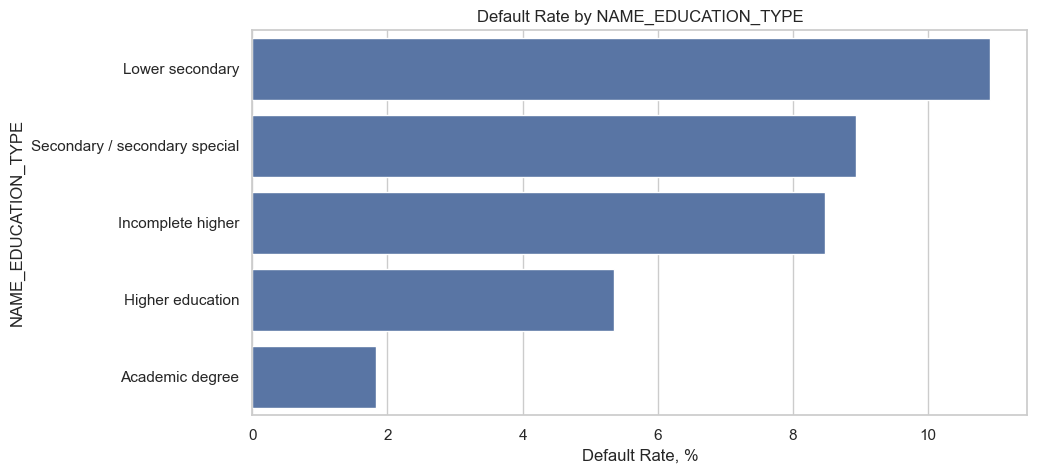

,NAME_EDUCATION_TYPE,count,default_rate
0,Lower secondary,3816,10.927673
1,Secondary / secondary special,218391,8.939929
2,Incomplete higher,10277,8.484966
3,Higher education,74863,5.355115
4,Academic degree,164,1.829268


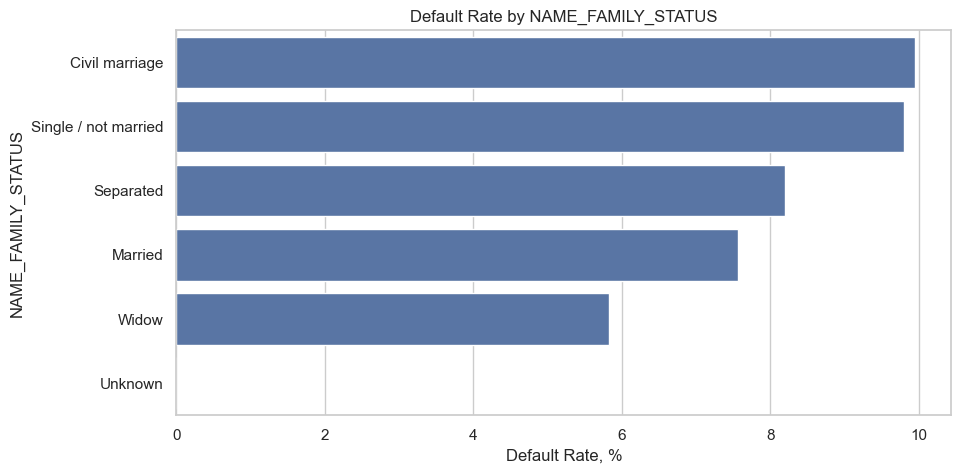

,NAME_FAMILY_STATUS,count,default_rate
0,Civil marriage,29775,9.944584
1,Single / not married,45444,9.807675
2,Separated,19770,8.194234
3,Married,196432,7.559868
4,Widow,16088,5.824217
5,Unknown,2,0.000000


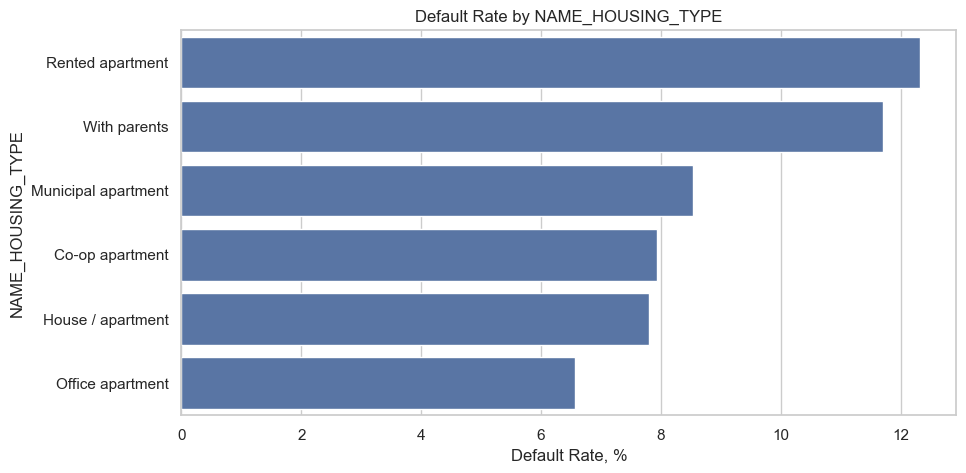

,NAME_HOUSING_TYPE,count,default_rate
0,Rented apartment,4881,12.313051
1,With parents,14840,11.698113
2,Municipal apartment,11183,8.539748
3,Co-op apartment,1122,7.932264
4,House / apartment,272868,7.795711
5,Office apartment,2617,6.572411


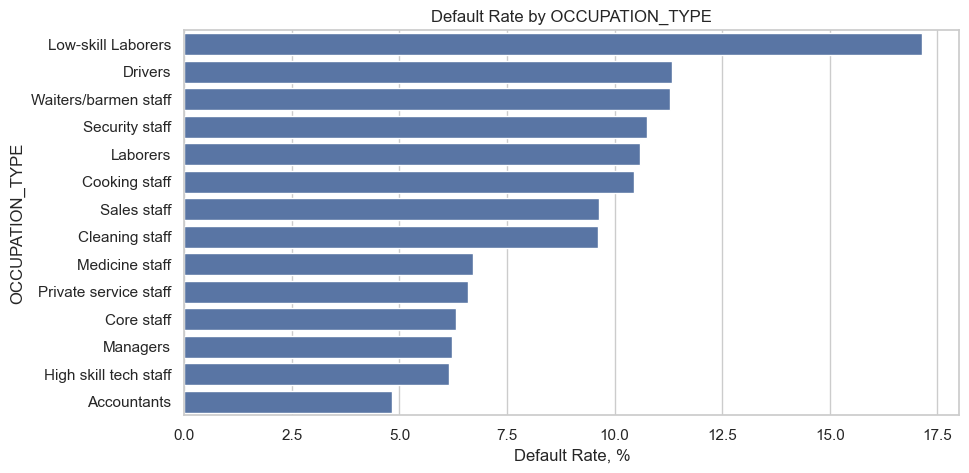

,OCCUPATION_TYPE,count,default_rate
0,Low-skill Laborers,2093,17.152413
1,Drivers,18603,11.326130
2,Waiters/barmen staff,1348,11.275964
3,Security staff,6721,10.742449
4,Laborers,55186,10.578770
5,Cooking staff,5946,10.443996
6,Sales staff,32102,9.631799
7,Cleaning staff,4653,9.606705
10,Medicine staff,8537,6.700246
11,Private service staff,2652,6.598793


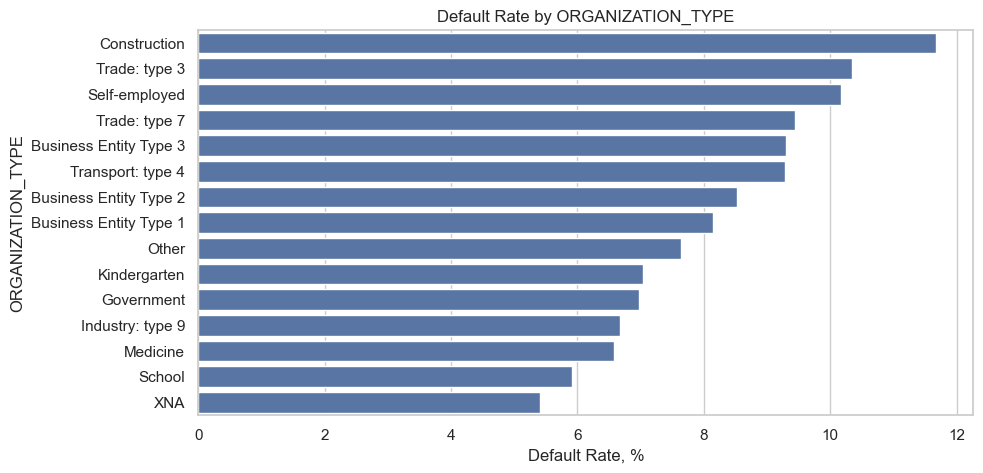

,ORGANIZATION_TYPE,count,default_rate
4,Construction,6721,11.679810
10,Trade: type 3,3492,10.337915
11,Self-employed,38412,10.173904
14,Trade: type 7,7831,9.449623
15,Business Entity Type 3,67992,9.299623
16,Transport: type 4,5398,9.281215
20,Business Entity Type 2,10553,8.528381
23,Business Entity Type 1,5984,8.138369
28,Other,16683,7.642510
33,Kindergarten,6880,7.034884


In [86]:
def get_category_default_rate(data, col):
    category_stats = (
        data.groupby(col, dropna=False)["TARGET"]
        .agg(["count", "mean"])
        .rename(columns={"count": "count", "mean": "default_rate"})
        .sort_values("default_rate", ascending=False)
        .reset_index()
    )

    category_stats["default_rate"] = category_stats["default_rate"] * 100

    return category_stats

def plot_default_rate_by_category(data, col, top_n=15):
    category_stats = get_category_default_rate(data, col)

    top_categories = (
        data[col]
        .value_counts(dropna=False)
        .head(top_n)
        .index
    )

    category_stats_top = category_stats[category_stats[col].isin(top_categories)]

    plt.figure(figsize=(10, 5))

    sns.barplot(
        data=category_stats_top,
        x="default_rate",
        y=col,
    )

    plt.title(f"Default Rate by {col}")
    plt.xlabel("Default Rate, %")
    plt.ylabel(col)

    plt.show()

    return category_stats_top

for col in main_categorical_features:
    display(plot_default_rate_by_category(application_train, col, top_n=15))

### Categorical features observations

В этом разделе были проанализированы категориальные признаки основной таблицы `application_train`. Для каждого признака были рассмотрены частоты категорий и доля дефолтов (`default_rate`) внутри каждой категории.

Некоторые категориальные признаки показывают заметные различия в уровне дефолта между группами клиентов.

По признаку `CODE_GENDER` видно, что у мужчин default rate выше, чем у женщин. Категория `XNA` содержит всего несколько наблюдений, поэтому её нельзя надёжно интерпретировать.

По типу кредита (`NAME_CONTRACT_TYPE`) клиенты с `Cash loans` имеют более высокий default rate, чем клиенты с `Revolving loans`.

Признак `NAME_INCOME_TYPE` также показывает различия между категориями. У клиентов с типом дохода `Working` default rate выше, чем у `Pensioner` и `State servant`. Категории `Maternity leave` и `Unemployed` имеют высокий default rate, но содержат очень мало наблюдений, поэтому выводы по ним ненадёжны.

По признаку `NAME_EDUCATION_TYPE` наблюдается понятная зависимость: клиенты с более высоким уровнем образования имеют более низкий default rate. Например, у категории `Higher education` доля дефолтов заметно ниже, чем у `Secondary / secondary special` и `Lower secondary`.

Семейное положение также связано с уровнем дефолта. Клиенты из категорий `Civil marriage` и `Single / not married` имеют более высокий default rate, чем клиенты из категории `Married`.

Тип жилья (`NAME_HOUSING_TYPE`) показывает, что клиенты, проживающие в арендованном жилье или с родителями, имеют более высокий default rate, чем клиенты с типом жилья `House / apartment`.

Признак `OCCUPATION_TYPE` является особенно информативным. Более высокий default rate наблюдается у категорий `Low-skill Laborers`, `Drivers`, `Security staff`, `Laborers` и других рабочих профессий. Более низкий default rate наблюдается у `Accountants`, `Managers`, `High skill tech staff` и похожих категорий. При этом в признаке есть много пропусков, которые можно рассматривать как отдельную категорию при дальнейшем preprocessing.

`ORGANIZATION_TYPE` также показывает различия между категориями. Более высокий default rate наблюдается у клиентов из сфер `Construction`, `Trade`, `Self-employed` и некоторых типов бизнеса. Более низкий default rate наблюдается у клиентов из категорий `School`, `Medicine`, `Government` и `XNA`.

Основной вывод: категориальные признаки содержат полезную информацию о социально-экономическом профиле клиента и связаны с кредитным риском. Их стоит сохранить для дальнейшего моделирования. На этапе preprocessing потребуется корректно обработать пропуски и закодировать категории.

## 12. Additional tables overview

В соревновании Home Credit кроме основной таблицы `application_train` есть несколько дополнительных таблиц с исторической информацией о клиентах.

Эти таблицы содержат данные о предыдущих заявках, кредитной истории, платежах и остатках по кредитам.

В этом разделе загрузим дополнительные таблицы и сделаем их базовый обзор:

- размер таблиц;
- основные ключи;
- количество уникальных клиентов;
- наличие пропусков;
- связь с основной таблицей `application_train`.

Глубокая обработка этих таблиц будет выполняться позже на этапе feature engineering, где исторические данные будут агрегироваться до уровня одного клиента.

In [90]:
bureau = pd.read_csv(RAW_DATA_DIR / "bureau.csv")
bureau_balance = pd.read_csv(RAW_DATA_DIR / "bureau_balance.csv")
previous_application = pd.read_csv(RAW_DATA_DIR / "previous_application.csv")
pos_cash_balance = pd.read_csv(RAW_DATA_DIR / "POS_CASH_balance.csv")
installments_payments = pd.read_csv(RAW_DATA_DIR / "installments_payments.csv")
credit_card_balance = pd.read_csv(RAW_DATA_DIR / "credit_card_balance.csv")

In [91]:
additional_tables = {
    "bureau": bureau,
    "bureau_balance": bureau_balance,
    "previous_application": previous_application,
    "pos_cash_balance": pos_cash_balance,
    "installments_payments": installments_payments,
    "credit_card_balance": credit_card_balance,
}

table_shapes = pd.DataFrame(
    {
        "table_name": additional_tables.keys(),
        "rows": [df.shape[0] for df in additional_tables.values()],
        "columns": [df.shape[1] for df in additional_tables.values()],
    }
).sort_values("rows", ascending=False)

table_shapes

,table_name,rows,columns
1,bureau_balance,27299925,3
4,installments_payments,13605401,8
3,pos_cash_balance,10001358,8
5,credit_card_balance,3840312,23
0,bureau,1716428,17
2,previous_application,1670214,37


In [92]:
for table_name, df in additional_tables.items():
    print(f"\n{table_name}")
    display(df.head())


bureau


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN



bureau_balance


,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C



previous_application


...

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0



installments_payments


,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585



credit_card_balance


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,AMT_PAYMENT_CURRENT,AMT_PAYMENT_TOTAL_CURRENT,AMT_RECEIVABLE_PRINCIPAL,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,1800.0,1800.0,0.000,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,2250.0,2250.0,60175.080,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,2250.0,2250.0,26926.425,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,11925.0,11925.0,224949.285,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,27000.0,27000.0,443044.395,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0


In [93]:
for table_name, df in additional_tables.items():
    key_columns = [col for col in df.columns if col.startswith("SK_ID")]

    print(f"{table_name}: {key_columns}")

bureau: ['SK_ID_CURR', 'SK_ID_BUREAU']
bureau_balance: ['SK_ID_BUREAU']
previous_application: ['SK_ID_PREV', 'SK_ID_CURR']
pos_cash_balance: ['SK_ID_PREV', 'SK_ID_CURR']
installments_payments: ['SK_ID_PREV', 'SK_ID_CURR']
credit_card_balance: ['SK_ID_PREV', 'SK_ID_CURR']


In [94]:
unique_clients_summary = []

for table_name, df in additional_tables.items():
    if "SK_ID_CURR" in df.columns:
        unique_clients_summary.append(
            {
                "table_name": table_name,
                "unique_SK_ID_CURR": df["SK_ID_CURR"].nunique(),
                "rows": df.shape[0],
                "avg_rows_per_client": df.shape[0] / df["SK_ID_CURR"].nunique(),
            }
        )
    else:
        unique_clients_summary.append(
            {
                "table_name": table_name,
                "unique_SK_ID_CURR": np.nan,
                "rows": df.shape[0],
                "avg_rows_per_client": np.nan,
            }
        )

unique_clients_summary = pd.DataFrame(unique_clients_summary).sort_values(
    "avg_rows_per_client",
    ascending=False
)

unique_clients_summary

,table_name,unique_SK_ID_CURR,rows,avg_rows_per_client
4,installments_payments,339587.0,13605401,40.064552
5,credit_card_balance,103558.0,3840312,37.083683
3,pos_cash_balance,337252.0,10001358,29.655445
0,bureau,305811.0,1716428,5.612709
2,previous_application,338857.0,1670214,4.928964
1,bureau_balance,NaN,27299925,NaN


In [95]:
# какая доля клиентов из application_train имеет записи в каждой дополнительной таблице
train_client_ids = set(application_train["SK_ID_CURR"])

client_coverage_summary = []

for table_name, df in additional_tables.items():
    if "SK_ID_CURR" in df.columns:
        table_client_ids = set(df["SK_ID_CURR"])

        clients_in_train = len(train_client_ids.intersection(table_client_ids))
        coverage_rate = clients_in_train / len(train_client_ids)

        client_coverage_summary.append(
            {
                "table_name": table_name,
                "train_clients_in_table": clients_in_train,
                "train_coverage_rate": coverage_rate,
            }
        )

client_coverage_summary = pd.DataFrame(client_coverage_summary).sort_values(
    "train_coverage_rate",
    ascending=False
)

client_coverage_summary

,table_name,train_clients_in_table,train_coverage_rate
3,installments_payments,291643,0.948399
1,previous_application,291057,0.946493
2,pos_cash_balance,289444,0.941248
0,bureau,263491,0.856851
4,credit_card_balance,86905,0.282608


In [96]:
missing_summaries = []

for table_name, df in additional_tables.items():
    missing_rate = df.isna().mean()
    high_missing = missing_rate[missing_rate > 0].sort_values(ascending=False)

    missing_summaries.append(
        {
            "table_name": table_name,
            "columns_with_missing": (missing_rate > 0).sum(),
            "max_missing_rate": missing_rate.max(),
            "mean_missing_rate": missing_rate.mean(),
        }
    )

missing_summaries = pd.DataFrame(missing_summaries).sort_values(
    "max_missing_rate",
    ascending=False
)

missing_summaries

,table_name,columns_with_missing,max_missing_rate,mean_missing_rate
2,previous_application,16,0.996437,0.179769
0,bureau,7,0.714735,0.135026
5,credit_card_balance,9,0.199981,0.066541
3,pos_cash_balance,2,0.002608,0.000652
4,installments_payments,2,0.000214,0.000053
1,bureau_balance,0,0.000000,0.000000


In [97]:
dtype_summary = []

for table_name, df in additional_tables.items():
    dtype_summary.append(
        {
            "table_name": table_name,
            "numeric_columns": df.select_dtypes(include=np.number).shape[1],
            "categorical_columns": df.select_dtypes(include=["object", "string"]).shape[1],
            "total_columns": df.shape[1],
        }
    )

dtype_summary = pd.DataFrame(dtype_summary)

dtype_summary

,table_name,numeric_columns,categorical_columns,total_columns
0,bureau,14,3,17
1,bureau_balance,2,1,3
2,previous_application,21,16,37
3,pos_cash_balance,7,1,8
4,installments_payments,8,0,8
5,credit_card_balance,22,1,23


In [98]:
additional_tables_overview = (
    table_shapes
    .merge(unique_clients_summary, on=["table_name", "rows"], how="left")
    .merge(client_coverage_summary, on="table_name", how="left")
    .merge(missing_summaries, on="table_name", how="left")
    .merge(dtype_summary, on="table_name", how="left")
)

additional_tables_overview

,table_name,rows,columns,unique_SK_ID_CURR,avg_rows_per_client,train_clients_in_table,train_coverage_rate,columns_with_missing,max_missing_rate,mean_missing_rate,numeric_columns,categorical_columns,total_columns
0,bureau_balance,27299925,3,NaN,NaN,NaN,NaN,0,0.000000,0.000000,2,1,3
1,installments_payments,13605401,8,339587.0,40.064552,291643.0,0.948399,2,0.000214,0.000053,8,0,8
2,pos_cash_balance,10001358,8,337252.0,29.655445,289444.0,0.941248,2,0.002608,0.000652,7,1,8
3,credit_card_balance,3840312,23,103558.0,37.083683,86905.0,0.282608,9,0.199981,0.066541,22,1,23
4,bureau,1716428,17,305811.0,5.612709,263491.0,0.856851,7,0.714735,0.135026,14,3,17
5,previous_application,1670214,37,338857.0,4.928964,291057.0,0.946493,16,0.996437,0.179769,21,16,37


### Additional tables overview observations

В этом разделе были загружены и рассмотрены дополнительные таблицы датасета Home Credit.

Дополнительные таблицы содержат историческую информацию о клиентах: предыдущие заявки, кредитную историю, платежи, POS/cash balance и данные по кредитным картам.

Размеры таблиц сильно отличаются. Самыми большими являются `bureau_balance`, `installments_payments` и `POS_CASH_balance`, которые содержат миллионы строк. Это говорит о том, что данные представлены не на уровне одного клиента, а на уровне исторических записей, платежей или ежемесячных наблюдений.

Большинство дополнительных таблиц имеют связь с основной таблицей через `SK_ID_CURR`. Исключением является `bureau_balance`, которая содержит только `SK_ID_BUREAU` и должна связываться с клиентом через таблицу `bureau`.

Покрытие клиентов из `application_train` различается между таблицами. `installments_payments`, `POS_CASH_balance` и `previous_application` покрывают более 94% клиентов, поэтому они являются особенно важными источниками информации для дальнейшего feature engineering. Таблица `bureau` покрывает около 86% клиентов, а `credit_card_balance` — только около 28%, так как история по кредитным картам есть не у всех клиентов.

В дополнительных таблицах один клиент может иметь много строк. Например, в `installments_payments` в среднем около 40 записей на клиента, в `POS_CASH_balance` около 30, а в `previous_application` около 5. Поэтому эти таблицы нельзя напрямую объединять с `application_train`. Перед объединением их нужно агрегировать до уровня `SK_ID_CURR`.

Некоторые таблицы содержат признаки с высокой долей пропусков, особенно `previous_application` и `bureau`. На этапе feature engineering такие признаки нужно будет дополнительно анализировать: часть из них можно удалить, а часть обработать через импутацию или специальные индикаторы пропусков.

Основной вывод: дополнительные таблицы содержат важную историческую информацию о клиентах и будут использоваться позже для создания агрегированных признаков на уровне клиента.

## 13. Dataset relationships

В этом разделе рассмотрим связи между таблицами датасета.

Главная таблица для обучения модели — `application_train`. В ней одна строка соответствует одной текущей заявке клиента, а целевая переменная `TARGET` показывает, был ли дефолт.

Дополнительные таблицы содержат историческую информацию. В них одному клиенту может соответствовать много строк: несколько прошлых заявок, несколько кредитов в бюро, много ежемесячных записей или платежей.

Поэтому дополнительные таблицы нельзя напрямую объединять с `application_train`. Сначала их нужно агрегировать до уровня клиента `SK_ID_CURR`, и только после этого присоединять к основной таблице.

### Main keys

Основные ключи в датасете:

- `SK_ID_CURR` — ID клиента / текущей заявки. Это главный ключ для связи с `application_train`;
- `SK_ID_PREV` — ID предыдущей заявки или предыдущего кредита;
- `SK_ID_BUREAU` — ID записи в кредитном бюро.

Связь таблиц выглядит так:

`application_train`
- связывается с `bureau` по `SK_ID_CURR`;
- связывается с `previous_application` по `SK_ID_CURR`;
- связывается с `POS_CASH_balance`, `installments_payments`, `credit_card_balance` по `SK_ID_CURR` и/или `SK_ID_PREV`.

`bureau`
- связывается с `bureau_balance` по `SK_ID_BUREAU`.

То есть `bureau_balance` не имеет прямого ключа `SK_ID_CURR`, поэтому для связи с клиентом её нужно сначала соединять или агрегировать через `bureau`.

### Dataset relationship schema

```text
application_train
│
├── bureau
│   └── bureau_balance
│
├── previous_application
│   ├── POS_CASH_balance
│   ├── installments_payments
│   └── credit_card_balance
│
└── application_test### Dataset relationship schema
```

```text
application_train
│
├── bureau
│   └── bureau_balance
│
├── previous_application
│   ├── POS_CASH_balance
│   ├── installments_payments
│   └── credit_card_balance
│
└── application_test
```

In [99]:
# проверим тип связи
records_per_client_summary = []

for table_name, df in additional_tables.items():
    if "SK_ID_CURR" in df.columns:
        records_per_client = df.groupby("SK_ID_CURR").size()

        records_per_client_summary.append(
            {
                "table_name": table_name,
                "min_records_per_client": records_per_client.min(),
                "median_records_per_client": records_per_client.median(),
                "mean_records_per_client": records_per_client.mean(),
                "max_records_per_client": records_per_client.max(),
            }
        )

records_per_client_summary = pd.DataFrame(records_per_client_summary).sort_values(
    "mean_records_per_client",
    ascending=False
)

records_per_client_summary

,table_name,min_records_per_client,median_records_per_client,mean_records_per_client,max_records_per_client
3,installments_payments,1,25.0,40.064552,372
4,credit_card_balance,1,22.0,37.083683,192
2,pos_cash_balance,1,22.0,29.655445,295
0,bureau,1,4.0,5.612709,116
1,previous_application,1,4.0,4.928964,77


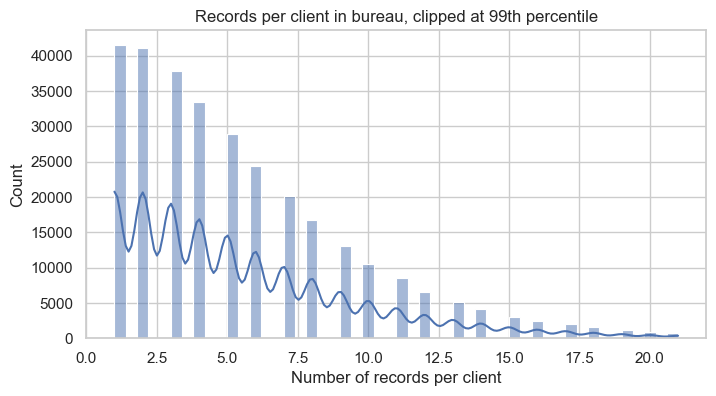

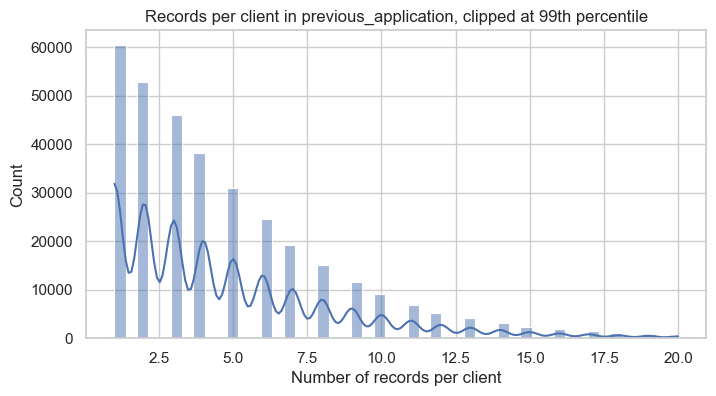

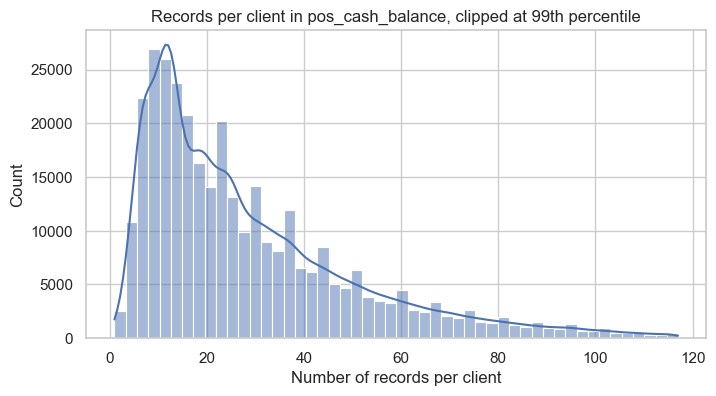

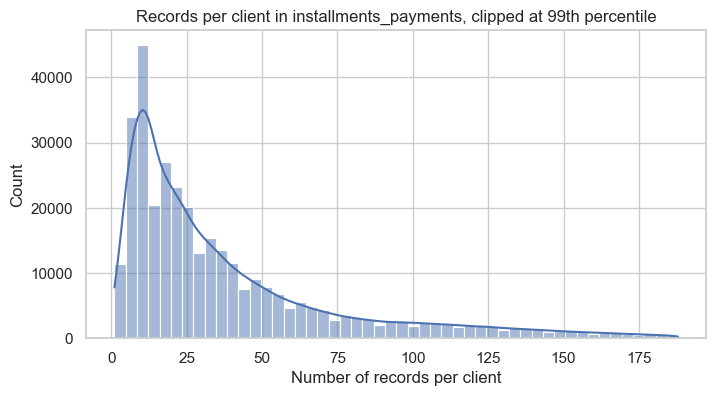

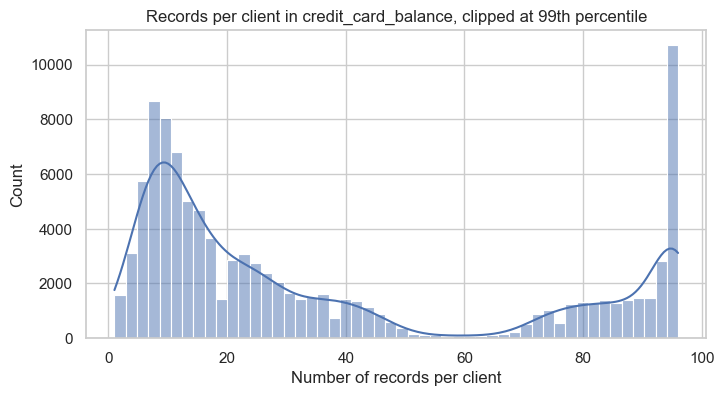

In [100]:
for table_name, df in additional_tables.items():
    if "SK_ID_CURR" in df.columns:
        records_per_client = df.groupby("SK_ID_CURR").size()

        upper_limit = records_per_client.quantile(0.99)

        plt.figure(figsize=(8, 4))

        sns.histplot(
            records_per_client[records_per_client <= upper_limit],
            bins=50,
            kde=True,
        )

        plt.title(f"Records per client in {table_name}, clipped at 99th percentile")
        plt.xlabel("Number of records per client")
        plt.ylabel("Count")

        plt.show()

### Dataset relationships observations

В этом разделе были рассмотрены связи между таблицами датасета.

Основная таблица `application_train` содержит одну строку на текущую заявку клиента и связана с большинством дополнительных таблиц через ключ `SK_ID_CURR`.

Дополнительные таблицы имеют структуру один-ко-многим: одному клиенту может соответствовать несколько записей в `bureau`, `previous_application`, `installments_payments`, `POS_CASH_balance` и `credit_card_balance`.

Таблица `bureau_balance` не содержит ключ `SK_ID_CURR` и связана с клиентом через таблицу `bureau` по ключу `SK_ID_BUREAU`.

Из-за структуры один-ко-многим дополнительные таблицы нельзя напрямую объединять с `application_train`, так как это приведёт к размножению строк. Перед объединением с основной таблицей исторические данные нужно агрегировать до уровня `SK_ID_CURR`.

На этапе feature engineering для каждой дополнительной таблицы будут созданы агрегированные признаки: количество исторических записей, средние и максимальные значения денежных признаков, количество активных и закрытых кредитов, доля отказанных или одобренных заявок, признаки просрочек и платежной дисциплины.

Основной вывод: дополнительные таблицы являются важным источником исторической информации о клиентах, но требуют предварительной агрегации перед использованием в модели.

## 14. Historical records per applicant

В этом разделе проанализируем, сколько исторических записей приходится на одного клиента в дополнительных таблицах.

Дополнительные таблицы имеют структуру один-ко-многим: одному клиенту может соответствовать несколько предыдущих заявок, кредитов, платежей или ежемесячных записей.

Количество таких записей само по себе может быть полезным признаком. Например, большое количество предыдущих заявок может отражать активную кредитную историю, а отсутствие записей в некоторых таблицах может означать отсутствие соответствующего типа кредитной истории.

Проверим количество записей на клиента в дополнительных таблицах и сравним эти значения между группами `TARGET = 0` и `TARGET = 1`.

In [101]:
historical_counts = application_train[["SK_ID_CURR", "TARGET"]].copy()

for table_name, df in additional_tables.items():
    if "SK_ID_CURR" in df.columns:
        counts = (
            df.groupby("SK_ID_CURR")
            .size()
            .rename(f"{table_name}_records_count")
            .reset_index()
        )

        historical_counts = historical_counts.merge(
            counts,
            on="SK_ID_CURR",
            how="left"
        )

historical_counts.head()

,SK_ID_CURR,TARGET,bureau_records_count,previous_application_records_count,pos_cash_balance_records_count,installments_payments_records_count,credit_card_balance_records_count
0,100002,1,8.0,1.0,19.0,19.0,NaN
1,100003,0,4.0,3.0,28.0,25.0,NaN
2,100004,0,2.0,1.0,4.0,3.0,NaN
3,100006,0,NaN,9.0,21.0,16.0,6.0
4,100007,0,1.0,6.0,66.0,66.0,NaN


In [102]:
count_features = [
    col for col in historical_counts.columns
    if col.endswith("_records_count")
]

historical_counts[count_features] = historical_counts[count_features].fillna(0)

historical_counts[count_features].describe().T

,count,mean,std,min,25%,50%,75%,max
bureau_records_count,307511.0,4.765114,4.496199,0.0,1.0,4.0,7.0,116.0
previous_application_records_count,307511.0,4.597237,4.180015,0.0,2.0,3.0,6.0,73.0
pos_cash_balance_records_count,307511.0,27.782339,24.580154,0.0,11.0,21.0,38.0,295.0
installments_payments_records_count,307511.0,37.694886,40.636357,0.0,11.0,23.0,48.0,372.0
credit_card_balance_records_count,307511.0,10.497072,24.507862,0.0,0.0,0.0,7.0,192.0


In [103]:
historical_counts.groupby("TARGET")[count_features].agg(["mean", "median"])

bureau_records_count        previous_application_records_count         \
                       mean median                               mean median   
TARGET                                                                         
0                  4.778464    4.0                           4.568111    3.0   
1                  4.613092    3.0                           4.928902    4.0   

       pos_cash_balance_records_count         \
                                 mean median   
TARGET                                         
0                           27.998518   21.0   
1                           25.320685   18.0   

       installments_payments_records_count         \
                                      mean median   
TARGET                                              
0                                37.891296   23.0   
1                                35.458328   22.0   

       credit_card_balance_records_count         
                                    mean median  
TARGET                                           
0                              10.605279    0.0  
1                               9.264894    0.0

In [104]:
historical_counts_corr = (
    historical_counts[count_features + ["TARGET"]]
    .corr(numeric_only=True)["TARGET"]
    .drop("TARGET")
    .sort_values()
    .to_frame("correlation_with_target")
)

historical_counts_corr

,correlation_with_target
pos_cash_balance_records_count,-0.029678
installments_payments_records_count,-0.016310
credit_card_balance_records_count,-0.014899
bureau_records_count,-0.010020
previous_application_records_count,0.023513


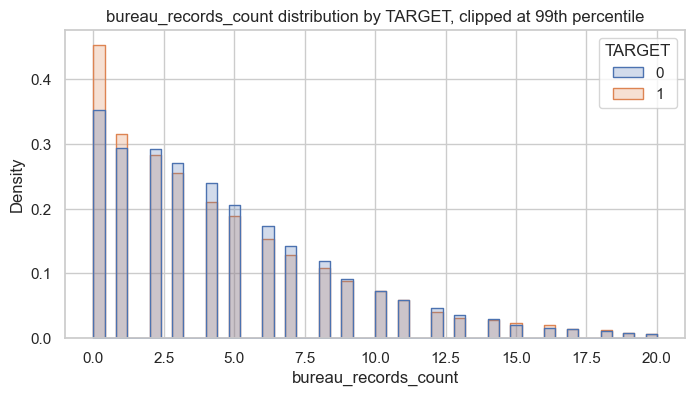

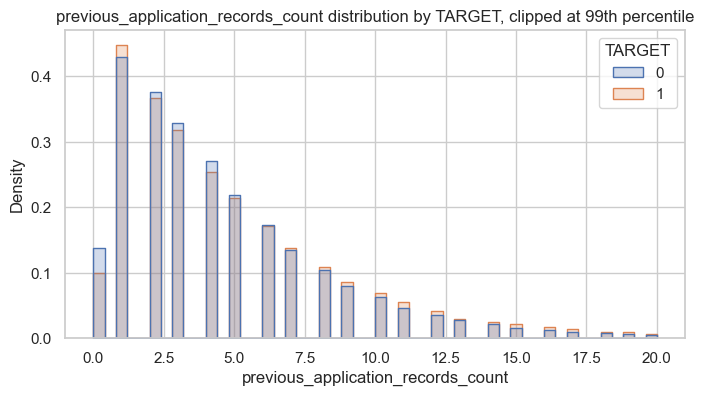

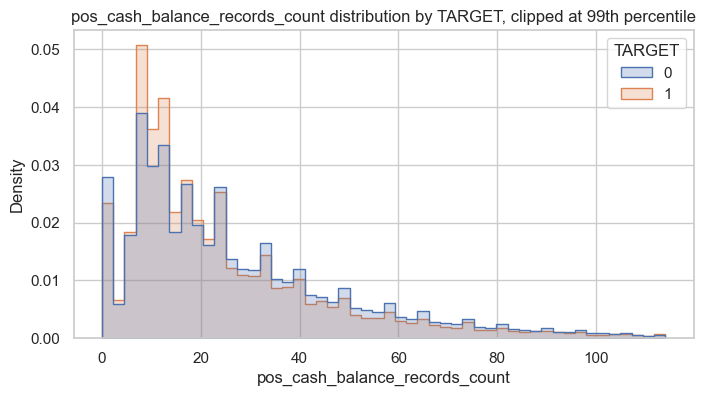

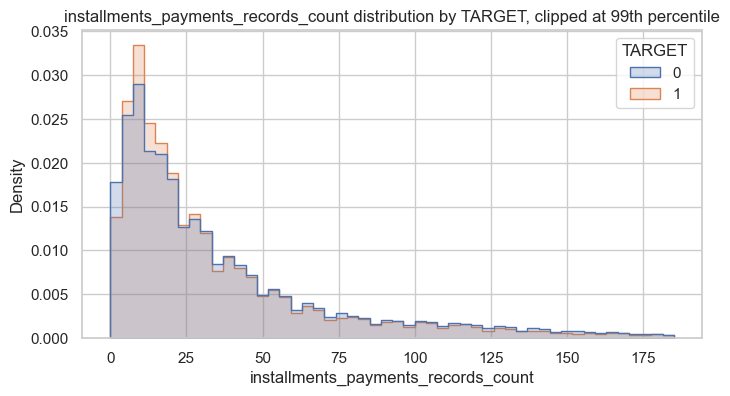

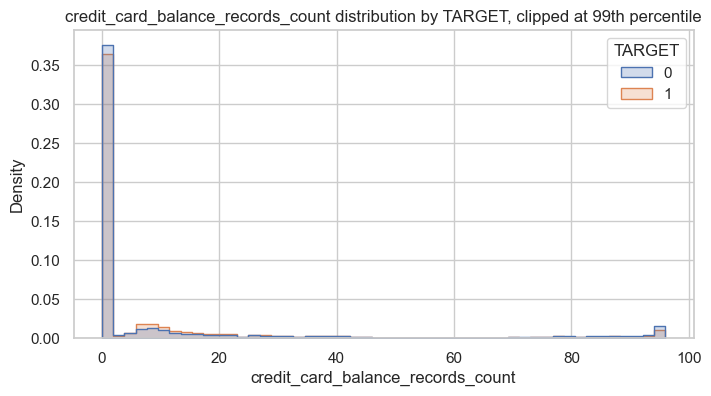

In [105]:
for col in count_features:
    upper_limit = historical_counts[col].quantile(0.99)

    plt.figure(figsize=(8, 4))

    sns.histplot(
        data=historical_counts[historical_counts[col] <= upper_limit],
        x=col,
        hue="TARGET",
        bins=50,
        stat="density",
        common_norm=False,
        element="step",
    )

    plt.title(f"{col} distribution by TARGET, clipped at 99th percentile")
    plt.xlabel(col)
    plt.ylabel("Density")

    plt.show()

In [106]:
for col in count_features:
    historical_counts[col.replace("_records_count", "_has_records")] = (
        historical_counts[col] > 0
    ).astype(int)

has_records_features = [
    col for col in historical_counts.columns
    if col.endswith("_has_records")
]

historical_counts[has_records_features].mean().sort_values(ascending=False)

installments_payments_has_records    0.948399
previous_application_has_records     0.946493
pos_cash_balance_has_records         0.941248
bureau_has_records                   0.856851
credit_card_balance_has_records      0.282608
dtype: float64

In [107]:
for col in has_records_features:
    has_records_stats = (
        historical_counts
        .groupby(col)["TARGET"]
        .agg(["count", "mean"])
        .rename(columns={"mean": "default_rate"})
        .reset_index()
    )

    has_records_stats["default_rate"] = has_records_stats["default_rate"] * 100

    print(f"\n{col}")
    display(has_records_stats)


bureau_has_records


,bureau_has_records,count,default_rate
0,0,44020,10.124943
1,1,263491,7.730055



previous_application_has_records


,previous_application_has_records,count,default_rate
0,0,16454,5.955999
1,1,291057,8.192553



pos_cash_balance_has_records


,pos_cash_balance_has_records,count,default_rate
0,0,18067,6.664084
1,1,289444,8.160819



installments_payments_has_records


,installments_payments_has_records,count,default_rate
0,0,15868,5.980590
1,1,291643,8.186721



credit_card_balance_has_records


,credit_card_balance_has_records,count,default_rate
0,0,220606,7.837955
1,1,86905,8.669237


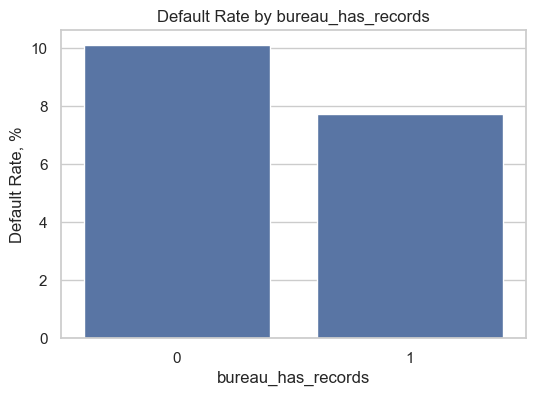

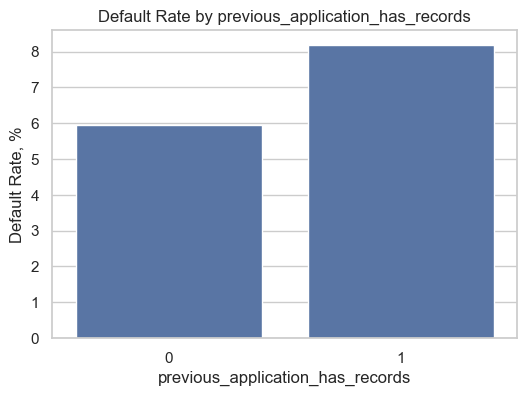

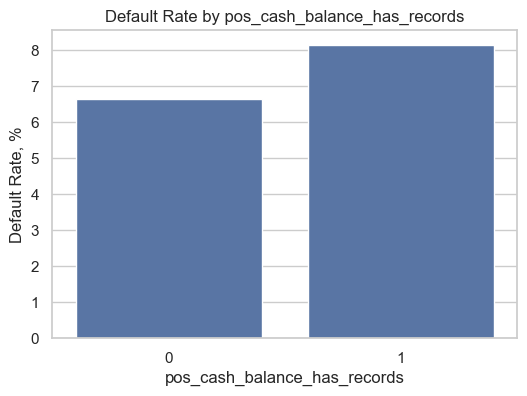

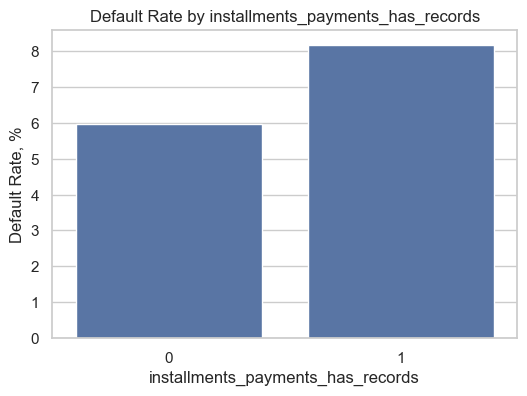

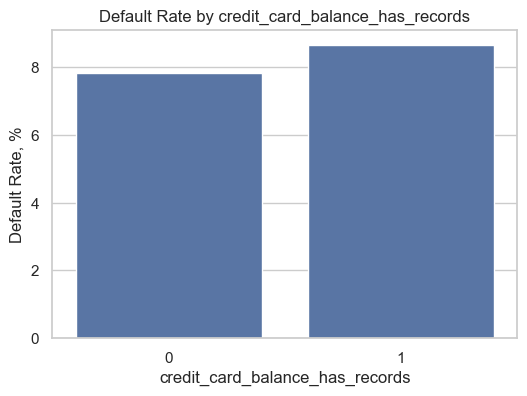

In [108]:
for col in has_records_features:
    has_records_stats = (
        historical_counts
        .groupby(col)["TARGET"]
        .mean()
        .mul(100)
        .reset_index()
        .rename(columns={"TARGET": "default_rate"})
    )

    plt.figure(figsize=(6, 4))

    sns.barplot(
        data=has_records_stats,
        x=col,
        y="default_rate",
    )

    plt.title(f"Default Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Default Rate, %")

    plt.show()

### Historical records per applicant observations

В этом разделе было проанализировано количество исторических записей на клиента в дополнительных таблицах.

Для каждой дополнительной таблицы были созданы признаки количества записей на клиента, например `bureau_records_count`, `previous_application_records_count`, `installments_payments_records_count`, а также бинарные признаки наличия истории, например `bureau_has_records`.

Корреляция количества исторических записей с `TARGET` в целом слабая. Это означает, что само количество записей не является сильным самостоятельным предиктором дефолта. Тем не менее направление связи отличается между таблицами.

Количество записей в `previous_application` имеет небольшую положительную корреляцию с `TARGET`, что может указывать на то, что клиенты с большим числом предыдущих заявок имеют немного более высокий риск дефолта.

Количество записей в `bureau`, `POS_CASH_balance`, `installments_payments` и `credit_card_balance` имеет слабую отрицательную корреляцию с `TARGET`, то есть большее количество записей в этих таблицах немного связано с меньшей вероятностью дефолта. Однако сила связи небольшая.

Анализ признаков наличия истории показал более интерпретируемые различия. Клиенты без записей в `bureau` имеют более высокий default rate, чем клиенты с кредитной историей в `bureau`. Это может означать, что отсутствие внешней кредитной истории связано с повышенным риском.

Для `previous_application`, `POS_CASH_balance`, `installments_payments` и `credit_card_balance` наличие записей связано с немного более высоким default rate. Это может отражать более высокую кредитную активность клиентов, у которых уже были предыдущие заявки, платежи или продукты.

Также видно, что покрытие таблиц различается. `installments_payments`, `previous_application` и `POS_CASH_balance` покрывают более 94% клиентов из train, `bureau` покрывает около 86%, а `credit_card_balance` — только около 28%.

Основной вывод: признаки количества исторических записей и наличия истории стоит сохранить для дальнейшего feature engineering. Хотя сами по себе они имеют слабую связь с `TARGET`, они дают полезную информацию о кредитной активности клиента и могут быть полезны модели в комбинации с другими агрегированными признаками.

## 15. Final EDA conclusions

В этом ноутбуке был проведён первичный разведочный анализ данных для задачи кредитного скоринга Home Credit Default Risk.

Основная цель EDA заключалась в том, чтобы понять структуру данных, распределение целевой переменной, особенности основных признаков, наличие пропусков и выбросов, а также связь разных групп признаков с дефолтом.

### Main conclusions

В основной таблице `application_train` одна строка соответствует одной текущей заявке клиента. Целевая переменная `TARGET` является бинарной: `0` означает отсутствие дефолта, `1` — дефолт.

Распределение целевой переменной несбалансированное: клиентов без дефолта значительно больше, чем клиентов с дефолтом. Это важно учитывать при дальнейшем моделировании, так как обычная accuracy может быть неинформативной метрикой. Для оценки моделей лучше использовать метрики, подходящие для несбалансированной классификации, например ROC-AUC, PR-AUC, recall, precision и F1-score.

Наиболее сильную связь с `TARGET` среди числовых признаков показали внешние скоринговые признаки `EXT_SOURCE_1`, `EXT_SOURCE_2` и `EXT_SOURCE_3`. Они имеют отрицательную корреляцию с целевой переменной: чем выше значение внешнего скорингового признака, тем ниже вероятность дефолта. Эти признаки являются одними из самых важных для дальнейшего моделирования.

Денежные признаки, такие как `AMT_INCOME_TOTAL`, `AMT_CREDIT`, `AMT_ANNUITY` и `AMT_GOODS_PRICE`, имеют скошенные распределения и выбросы. Их линейная связь с `TARGET` слабая, однако они важны для понимания финансового профиля клиента.

На основе денежных признаков были созданы ratio-признаки: отношение суммы кредита к доходу, аннуитетного платежа к доходу, аннуитетного платежа к сумме кредита и стоимости товара к сумме кредита. Эти признаки отражают финансовую нагрузку клиента. Их корреляция с `TARGET` также слабая, но они имеют понятный бизнес-смысл и могут быть полезны модели в комбинации с другими признаками.

Признаки, связанные с возрастом и датами (`DAYS_BIRTH`, `DAYS_EMPLOYED`, `DAYS_REGISTRATION`, `DAYS_ID_PUBLISH`), были преобразованы в более интерпретируемые признаки в годах. Возраст клиента оказался связан с кредитным риском: более молодые клиенты чаще представлены среди дефолтных клиентов. В признаке `DAYS_EMPLOYED` было найдено аномальное значение `365243`, которое было обработано отдельно через флаг `DAYS_EMPLOYED_ANOMALY`.

Категориальные признаки также показали различия в default rate между группами клиентов. Более высокий уровень дефолта наблюдается у некоторых категорий по полу, типу кредита, типу дохода, уровню образования, семейному положению, типу жилья, профессии и организации. Особенно информативными выглядят признаки `NAME_EDUCATION_TYPE`, `NAME_INCOME_TYPE`, `OCCUPATION_TYPE`, `ORGANIZATION_TYPE`, `NAME_HOUSING_TYPE` и `NAME_FAMILY_STATUS`.

При анализе категориальных признаков важно учитывать размер категории. Некоторые категории имеют высокий или низкий default rate, но содержат слишком мало наблюдений, поэтому выводы по ним могут быть ненадёжными.

Дополнительные таблицы содержат историческую информацию о клиентах: кредитную историю, предыдущие заявки, платежи, POS/cash balance и кредитные карты. Эти таблицы имеют структуру один-ко-многим: одному клиенту может соответствовать много исторических записей. Поэтому их нельзя напрямую объединять с `application_train`; сначала их нужно агрегировать до уровня `SK_ID_CURR`.

Анализ дополнительных таблиц показал, что `installments_payments`, `previous_application` и `POS_CASH_balance` покрывают более 94% клиентов из train, `bureau` покрывает около 86%, а `credit_card_balance` — около 28%. Это означает, что исторические таблицы являются важным источником информации для feature engineering.

Количество исторических записей и сам факт наличия истории также могут быть полезными признаками. Например, отсутствие записей в `bureau` связано с более высоким default rate, а наличие предыдущих заявок и платежной истории может отражать более высокую кредитную активность клиента.

### Next steps

На следующих этапах проекта необходимо:

1. Выполнить preprocessing основной таблицы:
   - обработать пропуски;
   - обработать аномальные значения;
   - закодировать категориальные признаки;
   - подготовить train/test данные.

2. Выполнить feature engineering:
   - сохранить полезные признаки из `application_train`;
   - добавить ratio-признаки;
   - добавить признаки возраста, стажа и флаги аномалий;
   - агрегировать дополнительные таблицы до уровня `SK_ID_CURR`.

3. Для дополнительных таблиц создать агрегированные признаки:
   - количество исторических записей;
   - наличие истории;
   - средние, максимальные, минимальные и суммарные значения числовых признаков;
   - доли статусов и категорий;
   - признаки просрочек;
   - признаки платёжной дисциплины;
   - признаки одобрения и отказов по предыдущим заявкам.

4. Объединить агрегированные признаки с основной таблицей.

5. Обучить baseline-модель и оценить качество на валидации.

6. Использовать feature importance и качество модели, чтобы понять, какие признаки действительно полезны.

### Final note

EDA показал, что задача требует аккуратной работы с разными типами данных: числовыми, категориальными, временными и историческими признаками.

Основная таблица `application_train` содержит важные признаки текущей заявки, но значительная часть потенциально полезной информации находится в дополнительных исторических таблицах. Поэтому ключевой следующий этап проекта — качественный feature engineering и агрегация исторических данных до уровня клиента.